# Network Models (Chapter 2)
## Jason LaRuez, Brendan Rooney
---
This notebook contains the code for generating many of the Chapter 2 (generative network model) figures from the dissertation "Topological Tools for the Analysis of Complex Networks and Higher-Order Networks". We apply zigzag persistence to the Erdos-Renyi random network model, Watts-Strogatz small-world lattice model, and the Barabasi-Albert preferential-attachment model (including a nonlinear preferential-attachment extension that bridges the gap between random and preferential-attachment).

Disclaimer: much of code used for the final plots was created using generative AI

---

## Loading/Installing packages

---


In [1]:
# For use with google colab
#from google.colab import drive
#drive.mount('/content/drive',force_remount=True)

!pip install dionysus==2.0.10
import dionysus as d # C++ package with python bindings for persistent homology
import networkx as nx # Network structures
import numpy as np # Numpy arrays and operations
import random # Random sampling for network models
from itertools import combinations, product # For getting different simplices and all combinations of lists

import matplotlib.pyplot as plt # Plotting
import matplotlib.lines as mlines
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import time # Timing simulations
from tqdm.notebook import trange, tqdm # Allows for real-time progress bar of simulations

import gc # Memory management
import pickle # Takes environment variables and saves them as is
import gzip # Allows for compression of saved files
from joblib import Parallel, delayed # Parallelization functions
import multiprocessing # Get number of cpu cores
import math
from math import comb
import bisect
import os
import collections

from NetworkModels import *

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
    'axes.grid':         True,
    'grid.linewidth':    0.4
})

Mounted at /content/drive


In [2]:
# ============================================================
# Field extractors
# NLPA format: [Betti, SimplexCounts, Euler, D, cycleR, clusterC]
# ER, RA/BA format: [Betti, SimplexCounts, Euler, cycleR, clusterC]
# ============================================================

fields = {
    r'$\beta_0$ (connected components)':                          lambda e: e[0][0],
    r'$\tilde{\beta}_0=\beta_0/N$':                  lambda e: np.where(
                                               sc_col(e, 0) > 0,
                                               e[0][0] / sc_col(e, 0), 0.0),
    r'$\beta_1$ (tunnels)':                          lambda e: e[0][1],
    r'$\tilde{\beta}_1=\beta_1/N_1$':                  lambda e: np.where(
                                               sc_col(e, 1) > 0,
                                               e[0][1] / sc_col(e, 1), 0.0),
    r'$\beta_2$ (voids)':                          lambda e: e[0][2],
    r'$\tilde{\beta}_2=\beta_2/N_2$':                  lambda e: np.where(
                                               sc_col(e, 2) > 0,
                                               e[0][2] / sc_col(e, 2), 0.0),
    r'$\chi$ (Euler characteristic)':                             lambda e: np.array(e[2], dtype=float),
    r'$\bar{C}$ (avg. clust. coeff.)':        lambda e: np.array(e[4], dtype=float),
    r'$N_2$ (triangles)':               lambda e: sc_col(e, 2),
    r'$N_3$ (tetrahedra)':               lambda e: sc_col(e, 3),
    r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)':        lambda e: cR1(e)
                                                      - e[0][1].astype(float),
    r'$\chi$ (Euler characteristic)':              lambda e: e[2],
    r'$\gamma_1$ (1-filling efficiency)':                         lambda e: np.where(
                                               sc_col(e, 2) > 0,
                                               (cR1(e) - e[0][1].astype(float))
                                               / sc_col(e, 2), 0.0),
    r'$\mathcal{CR}_2 - \beta_2$ (filled voids)':        lambda e: cR2(e)
                                                      - e[0][2].astype(float),
    r'$\gamma_2$ (2-filling efficiency)':                         lambda e: np.where(
                                               sc_col(e, 3) > 0,
                                               (cR2(e) - e[0][2].astype(float))
                                               / sc_col(e, 3), 0.0),
}

fields_ws = {
    r'$\beta_1$ (tunnels)':
        lambda e: e[0][1],
    r'$\tilde{\beta}_1=\beta_1/N_1$':
        lambda e: np.where(sc_col_ws(e[1], 1) > 0,
                           e[0][1] / sc_col_ws(e[1], 1), 0.0),
    r'$\beta_2$ (voids)':
        lambda e: e[0][2],
    r'$\tilde{\beta}_2=\beta_2/N_2$':
        lambda e: np.where(sc_col_ws(e[1], 2) > 0,
                           e[0][2] / sc_col_ws(e[1], 2), 0.0),
    r'$N_2$ (triangles)':
        lambda e: sc_col_ws(e[1], 2),
    r'$N_3$ (tetrahedra)':
        lambda e: sc_col_ws(e[1], 3),
    r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)':
        lambda e: cR1_ws(e) - e[0][1].astype(float),
    r'$\gamma_1$ (1-filling efficiency)':
        lambda e: np.where(sc_col_ws(e[1], 2) > 0,
                           (cR1_ws(e) - e[0][1].astype(float))
                           / sc_col_ws(e[1], 2), 0.0),
    r'$\mathcal{CR}_2 - \beta_2$ (filled voids)':
        lambda e: cR2_ws(e) - e[0][2].astype(float),
    r'$\gamma_2$ (2-filling efficiency)':
        lambda e: np.where(sc_col_ws(e[1], 3) > 0,
                           (cR2_ws(e) - e[0][2].astype(float))
                           / sc_col_ws(e[1], 3), 0.0),
    r'$\bar{C}$ (avg. clust. coeff.)':
        lambda e: np.array(e[3], dtype=float),
    r'$L$ (char. path length)':
        lambda e: np.array(e[4], dtype=float),
}

fields_nlpa = {
    r'$\beta_1$ (tunnels)':                          lambda e: e[0][1],
    r'$\tilde{\beta}_1=\beta_1/N_1$':                  lambda e: np.where(
                                               sc_col(e, 1) > 0,
                                               e[0][1] / sc_col(e, 1), 0.0),
    r'$\beta_2$ (voids)':                          lambda e: e[0][2],
    r'$\tilde{\beta}_2=\beta_2/N_2$':                  lambda e: np.where(
                                               sc_col(e, 2) > 0,
                                               e[0][2] / sc_col(e, 2), 0.0),
    r'$N_2$ (triangles)':                              lambda e: sc_col(e, 2),
    r'$N_3$ (tetrahedra)':                              lambda e: sc_col(e, 3),
    r'$\chi$ (Euler characteristic)':                             lambda e: e[2],
    r'$\bar{C}$ (avg. clust. coeff.)':        lambda e: e[5],
    r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)':        lambda e: (cR1_nlpa(e)
                                                       - e[0][1].astype(float)),
    r'$\mathcal{CR}_2 - \beta_2$ (filled voids)':        lambda e: (cR2_nlpa(e)
                                                       - e[0][2].astype(float)),
    r'$\gamma_1$ (1-filling efficiency)':                         lambda e: np.where(
                                               sc_col(e, 2) > 0,
                                               (cR1_nlpa(e)
                                                - e[0][1].astype(float))
                                               / sc_col(e, 2), 0.0),
    r'$\gamma_2$ (2-filling efficiency)':                         lambda e: np.where(
                                               sc_col(e, 3) > 0,
                                               (cR2_nlpa(e)
                                                - e[0][2].astype(float))
                                               / sc_col(e, 3), 0.0),
}


---
# Generating networks from models
---

## Sequential Erdos Renyi

In [ ]:
# Set N to be list containing numbers of nodes to be in the network; P to be the
# terminal edge density
N = [20]; P = 1; iteration = 1

for n in tqdm(N):
  Betti, SimplexCounts, Euler, cycleR, clusterC = PH_ErdosRenyi(n, p = P, timing = True)
  my_data = [Betti,SimplexCounts, Euler, cycleR, clusterC]; output = open('ErdosRenyi/ER_'+str(n)+'_'+str(P).replace('.','_')+'_'+str(iteration)+'.pkl','wb')
  pickle.dump(my_data, output); output.close()

## Parallel Erdos Renyi

In [ ]:
# Set N to be list containing numbers of nodes to be in the network; P to be the
# terminal edge density
N = [150]; P = [0.5]; iterations = list(range(1,101))
params = [N, P, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(ParallelCall_ER)(param) for param in tqdm(params))

  0%|          | 0/100 [00:00<?, ?it/s]

## Sequential Barabasi-Albert

In [ ]:
# Set n to be the terminal number of nodes, and K to be a set of parameters
# [k], where k is the number of nodes a newly added vertex is initially
# preferentially attached to
n = 10000; K = [5,10];

for k in tqdm(K):
  Betti, SimplexCounts, Euler = PH_BarabasiAlbert(n,k,True)
  my_data = [Betti, SimplexCounts, Euler]; output = open('BarabasiAlbert/BA_'+str(n)+'_'+str(k)+'.pkl','wb')
  pickle.dump(my_data, output); output.close()

## Parallel Barabasi-Albert

In [ ]:
# Set N to be the terminal number of nodes, and K to be a set of parameters
# [k], where k is the number of nodes a newly added vertex is initially
# preferentially attached to
N = [10000]; K = [2,3,4,5,6,7,8,9,10,15,20]; iterations = list(range(1,101))
params = [N, K, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(ParallelCall_BA)(param) for param in tqdm(params))

## Sequential Random-Attachment

In [ ]:
# Set n to be the terminal number of nodes, and K to be a set of parameters
# [k], where k is the number of nodes a newly added vertex is initially
# randomly attached to
n = 10000; K = [11,12,13,14,15];

for k in tqdm(K):
  Betti, SimplexCounts, Euler = PH_RandomAttachment(n,k,False)
  my_data = [Betti, SimplexCounts, Euler]; output = open('RandomAttachment/RA_'+str(n)+'_'+str(k)+'.pkl','wb')
  pickle.dump(my_data, output); output.close()

# Parallel Random-Attachment

In [ ]:
N = [10000]; K = [15]; iterations = list(range(1,101))
params = [N, K, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(ParallelCall_RA)(param) for param in tqdm(params))

  0%|          | 0/100 [00:00<?, ?it/s]

## Sequential Watts-Strogatz

In [ ]:
# Let N be a set of node counts for the network, with
# K being a set of average node degrees (node degrees
# in the original ring lattice)
N = [1000,2000,3000,4000,5000]; K = [4,8];

for n in tqdm(N):
  for k in tqdm(K):
    Betti, SimplexCounts, Euler = ZZPH_WattsStrogatz(n,k,True)
    my_data = [Betti, SimplexCounts, Euler]; output = open('WattsStrogatz/WS_'+str(n)+'_'+str(k)+'.pkl','wb')
    pickle.dump(my_data, output); output.close()

## Parallel Watts-Strogatz

In [ ]:
# Let N be a set of node counts for the network, with
# K being a set of average node degrees (node degrees
# in the original ring lattice)
N = [25,50,100,200]; K = [4,6,8,10]; iterations = range(1,101)
params = [N, K, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(ParallelCall_WS)(param) for param in tqdm(params))

## Parallel NLPA

In [ ]:
# Set N to be the terminal number of nodes, and K to be a set of parameters
# [k], where k is the number of nodes a newly added vertex is initially
# preferentially attached to
N = [10000]; K = [2,3,4,5]; alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.1, 1.2, 1.3, 1.4, 1.5];
iterations = list(range(1,11))
params = [N, K, alphas, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(ParallelCall_NLPA)(param) for param in tqdm(params))

100%|██████████| 140/140 [00:03<00:00, 38.67it/s]


---
# Generating dissertation plots
---

## Loading Erdos-Renyi graph data

In [3]:
base_path_er  = 'ErdosRenyi/'
iterations = list(range(1, 101))
num_cores  = 8

# Parameter combinations: (N, P)
NP_combinations = [(5,1), (10, 1), (15,1), (20, 1), (25,1), (30,0.75), (35, 0.75), (40, 0.75), (45, 0.75), (50, 0.75), (55, 0.6), (60, 0.6), (65, 0.6),
                   (70, 0.6), (75, 0.6), (80, 0.6), (85, 0.6), (90, 0.6), (95, 0.6), (100, 0.6), (150, 0.5)]

# Build full parameter list across all (n, p) combinations
all_params = [(n, p, iteration) for n, p in NP_combinations for iteration in iterations]

results = Parallel(n_jobs=num_cores, backend='loky')(
    delayed(load_single_er)(n, p, iteration, base_path_er)
    for n, p, iteration in tqdm(all_params, desc='Loading ER files')
)

# data_er[n][p][iteration] = [Betti, SimplexCounts, Euler, cycleR, clusterC]
data_er = {
    n: {p: {} for n2, p in NP_combinations if n2 == n}
    for n, _ in NP_combinations}
missing   = 0
corrupted = 0
loaded    = 0

for n, p, iteration, entry, status in results:
    data_er[n][p][iteration] = entry
    if status == 'ok':
        loaded += 1
    elif status == 'missing':
        missing += 1
    else:
        corrupted += 1
        print(f'  n={n}, p={p}, iter={iteration}: {status}')

print(f'\nLoaded: {loaded} / {len(all_params)}')
print(f'Missing: {missing}, Corrupted: {corrupted}')

Loading ER files:   0%|          | 0/2100 [00:00<?, ?it/s]


Loaded: 2100 / 2100
Missing: 0, Corrupted: 0


## Plotting Erdos-Renyi results

/tmp/ipykernel_49880/2784467921.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  n_cmap_er   = cm.get_cmap('plasma', n_n_er)
/tmp/ipykernel_49880/245365849.py:15: RuntimeWarning: invalid value encountered in divide
  e[0][1] / sc_col(e, 1), 0.0),
/tmp/ipykernel_49880/245365849.py:19: RuntimeWarning: invalid value encountered in divide
  e[0][2] / sc_col(e, 2), 0.0),


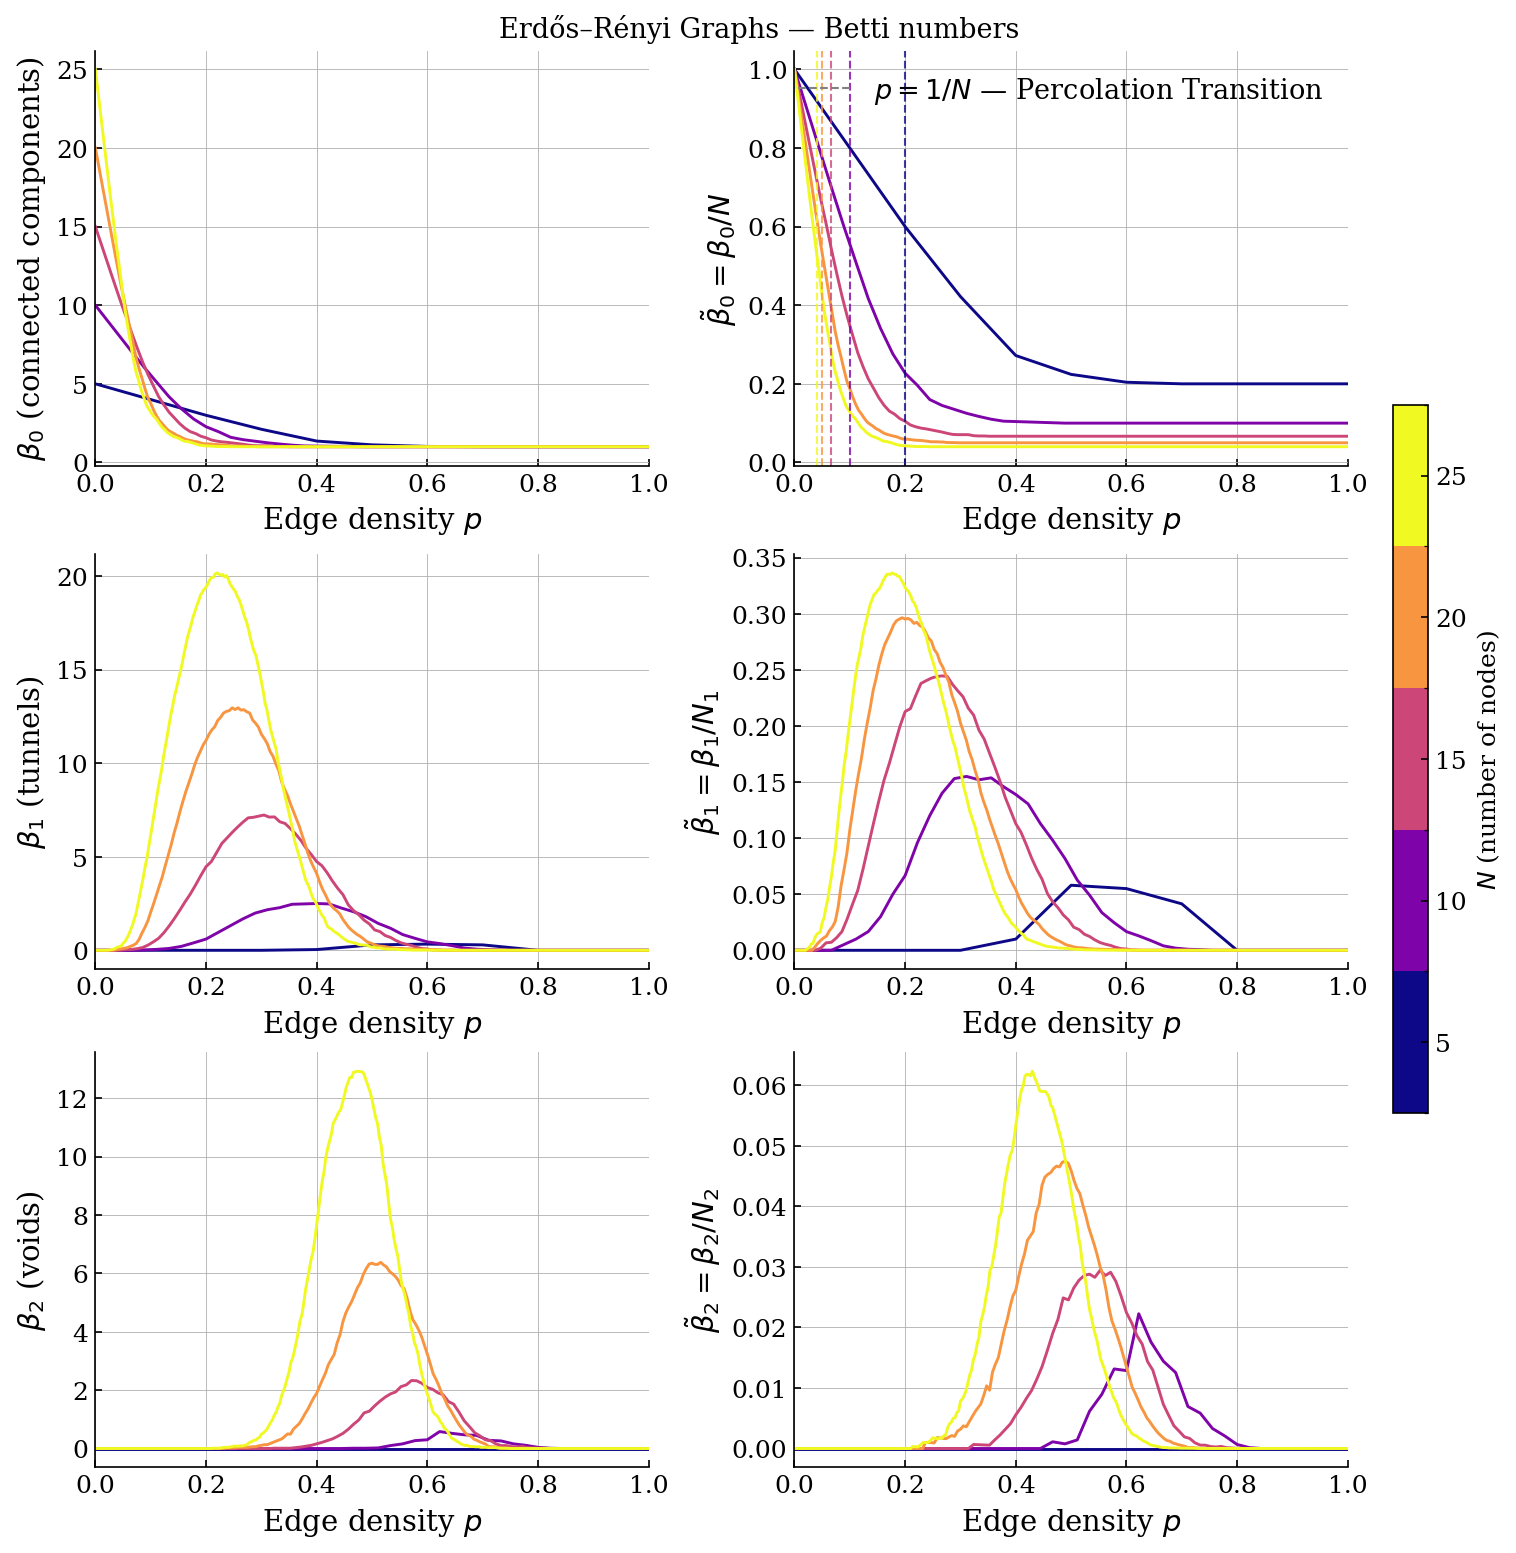

Saved: fig_ER_betti


/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: divide by zero encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: invalid value encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:35: RuntimeWarning: divide by zero encountered in divide
  (cR2(e) - e[0][2].astype(float))
/tmp/ipykernel_49880/245365849.py:35: RuntimeWarning: invalid value encountered in divide
  (cR2(e) - e[0][2].astype(float))


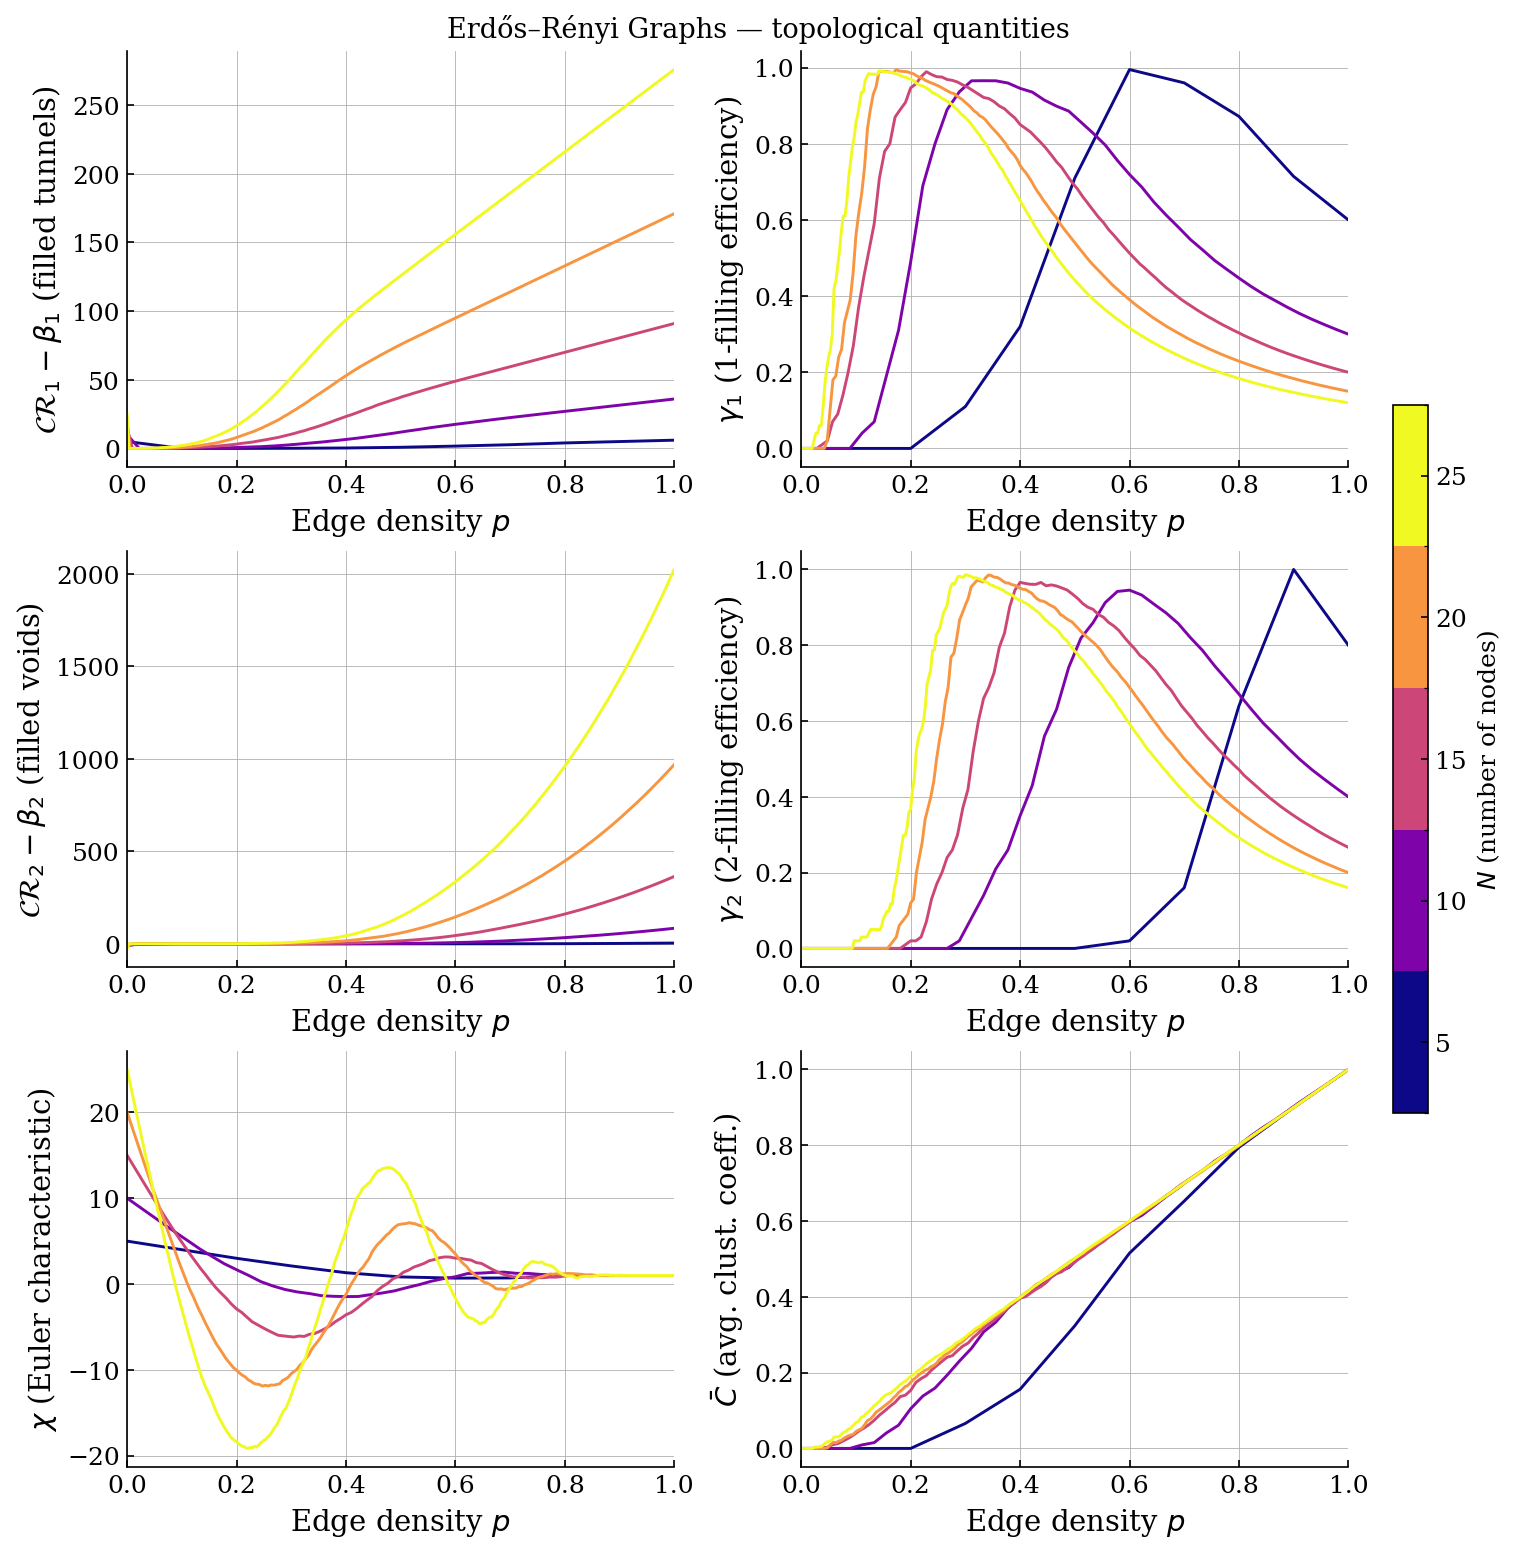

Saved: fig_ER_topology


In [4]:
# Only the p=1 subset
N_er_plot = [5, 10, 15, 20, 25]
p_er      = 1

# Discrete colormap over N values
n_n_er      = len(N_er_plot)
n_cmap_er   = cm.get_cmap('plasma', n_n_er)
n_colors_er = {n: n_cmap_er(i) for i, n in enumerate(N_er_plot)}
n_boundaries_er = np.arange(n_n_er + 1) - 0.5
n_norm_er       = mcolors.BoundaryNorm(n_boundaries_er, ncolors=n_n_er)

# ============================================================
# Figure 1: β0,β̃0 | β1,β̃1 | β2,β̃2
# ============================================================
fig1_layout = [
    (r'$\beta_0$ (connected components)',  r'$\tilde{\beta}_0=\beta_0/N$'),
    (r'$\beta_1$ (tunnels)',  r'$\tilde{\beta}_1=\beta_1/N_1$'),
    (r'$\beta_2$ (voids)',  r'$\tilde{\beta}_2=\beta_2/N_2$'),
]

fig1, axes1 = plt.subplots(3, 2, figsize=(10, 10),
                             constrained_layout=True)

for row_idx, (left_label, right_label) in enumerate(fig1_layout):
    is_bottom = (row_idx == 2)
    for col_idx, label in enumerate([left_label, right_label]):
        ax       = axes1[row_idx][col_idx]
        field_fn = fields[label]

        for n in N_er_plot:
            x, mean = get_mean_traj_er(data_er, n, p_er, iterations, field_fn)
            if x is None: continue
            ax.plot(x, mean,
                    color=n_colors_er[n],
                    lw=1.4)

        # Percolation transition lines in the β̃0 panel only
        if label == r'$\tilde{\beta}_0=\beta_0/N$':
            perc_handle = None
            for n in N_er_plot:
                line = ax.axvline(x = 1/n, color = n_colors_er[n],
                    lw    = 1.0, linestyle = '--', alpha = 0.8)
                if perc_handle is None:
                    perc_handle = line

            # Single legend entry for all percolation lines
            import matplotlib.lines as mlines
            perc_proxy = mlines.Line2D([], [], color     = 'gray',
                lw = 1.0, linestyle = '--', label = r'$p = 1/N$ — Percolation Transition')
            ax.legend(handles=[perc_proxy], frameon=False, fontsize=13, loc='upper right')

        ax.set_ylabel(label)
        ax.set_xlim(0, 1)
        ax.set_xlabel(r'Edge density $p$')

add_discrete_cbar_er(fig1, axes1[:, :], n_cmap_er, n_norm_er, n_n_er, N_er_plot, shrink=0.5)
fig1.suptitle(
    r'Erdős–Rényi Graphs — Betti numbers',
    fontsize=13, y=1.02
)
fig1.savefig(base_path_er + 'fig_ER_betti.pdf', dpi=300, bbox_inches='tight')
fig1.savefig(base_path_er + 'fig_ER_betti.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_ER_betti')

# ============================================================
# Figure 2: CR1-β1,γ1 | CR2-β2,γ2 | χ,clusterC
# ============================================================
fig2_layout = [
    (r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)',   r'$\gamma_1$ (1-filling efficiency)'),
    (r'$\mathcal{CR}_2 - \beta_2$ (filled voids)',   r'$\gamma_2$ (2-filling efficiency)'),
    (r'$\chi$ (Euler characteristic)',                         r'$\bar{C}$ (avg. clust. coeff.)'),
]

fig2, axes2 = plt.subplots(3, 2, figsize=(10, 10),
                             constrained_layout=True)

for row_idx, (left_label, right_label) in enumerate(fig2_layout):
    is_bottom = (row_idx == 2)
    for col_idx, label in enumerate([left_label, right_label]):
        ax       = axes2[row_idx][col_idx]
        field_fn = fields[label]

        for n in N_er_plot:
            x, mean = get_mean_traj_er(data_er, n, p_er, iterations, field_fn)
            if x is None: continue
            ax.plot(x, mean, color=n_colors_er[n], lw=1.4)

        ax.set_ylabel(label)
        ax.set_xlim(0, 1)

        ax.set_xlabel(r'Edge density $p$')

add_discrete_cbar_er(fig2, axes2[:, :], n_cmap_er, n_norm_er, n_n_er, N_er_plot, shrink=0.5)
fig2.suptitle(
    r'Erdős–Rényi Graphs — topological quantities',
    fontsize=13, y=1.02
)
fig2.savefig(base_path_er + 'fig_ER_topology.pdf', dpi=300, bbox_inches='tight')
fig2.savefig(base_path_er + 'fig_ER_topology.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_ER_topology')

/tmp/ipykernel_49880/2411873368.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  n_cmap_all  = cm.get_cmap('plasma', n_k)
/tmp/ipykernel_49880/245365849.py:15: RuntimeWarning: invalid value encountered in divide
  e[0][1] / sc_col(e, 1), 0.0),
/tmp/ipykernel_49880/245365849.py:19: RuntimeWarning: invalid value encountered in divide
  e[0][2] / sc_col(e, 2), 0.0),


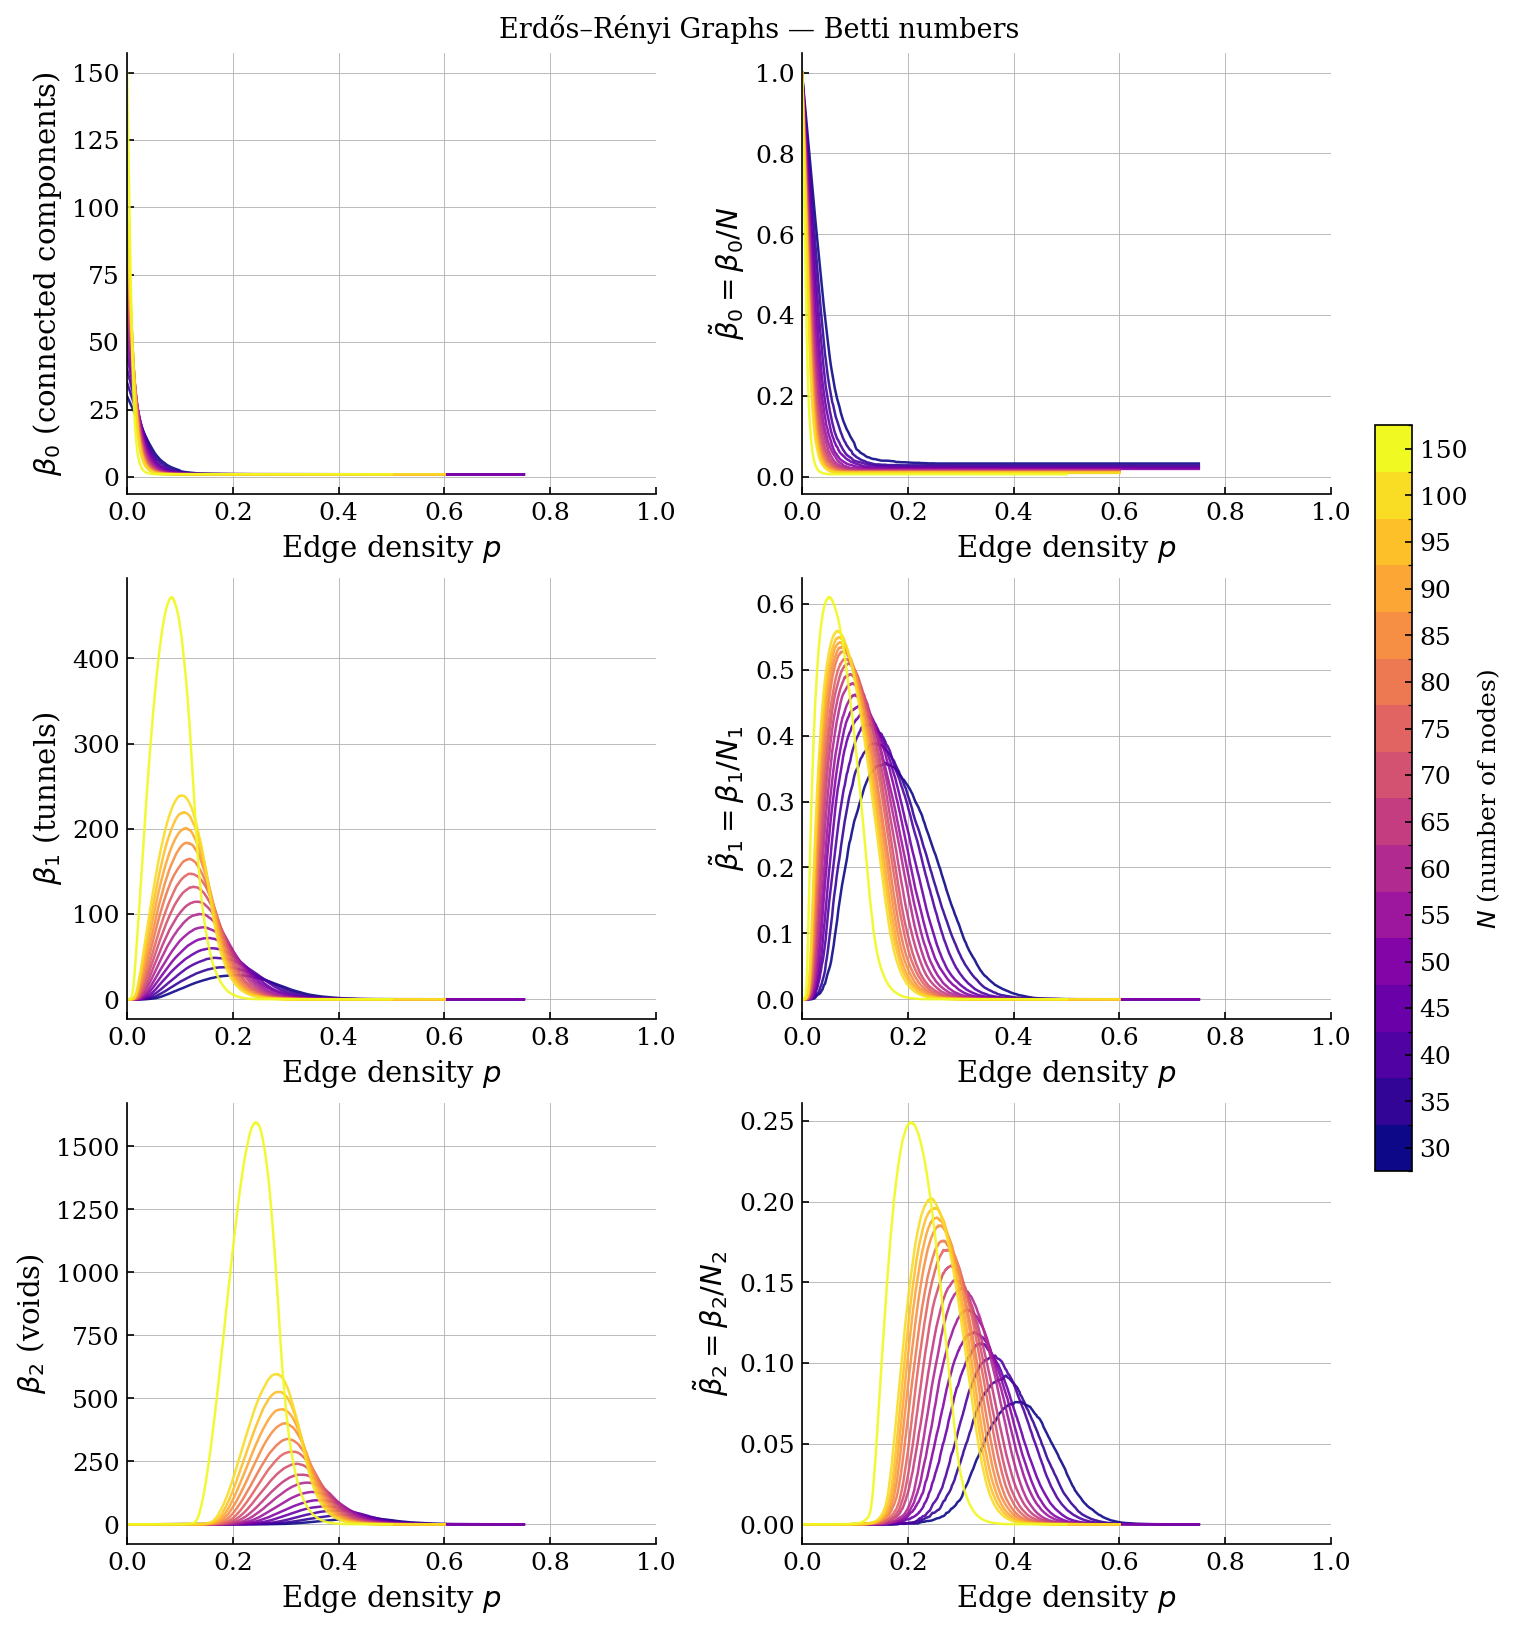

Saved: fig_ER_all_betti


/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: divide by zero encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: invalid value encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:35: RuntimeWarning: divide by zero encountered in divide
  (cR2(e) - e[0][2].astype(float))
/tmp/ipykernel_49880/245365849.py:35: RuntimeWarning: invalid value encountered in divide
  (cR2(e) - e[0][2].astype(float))


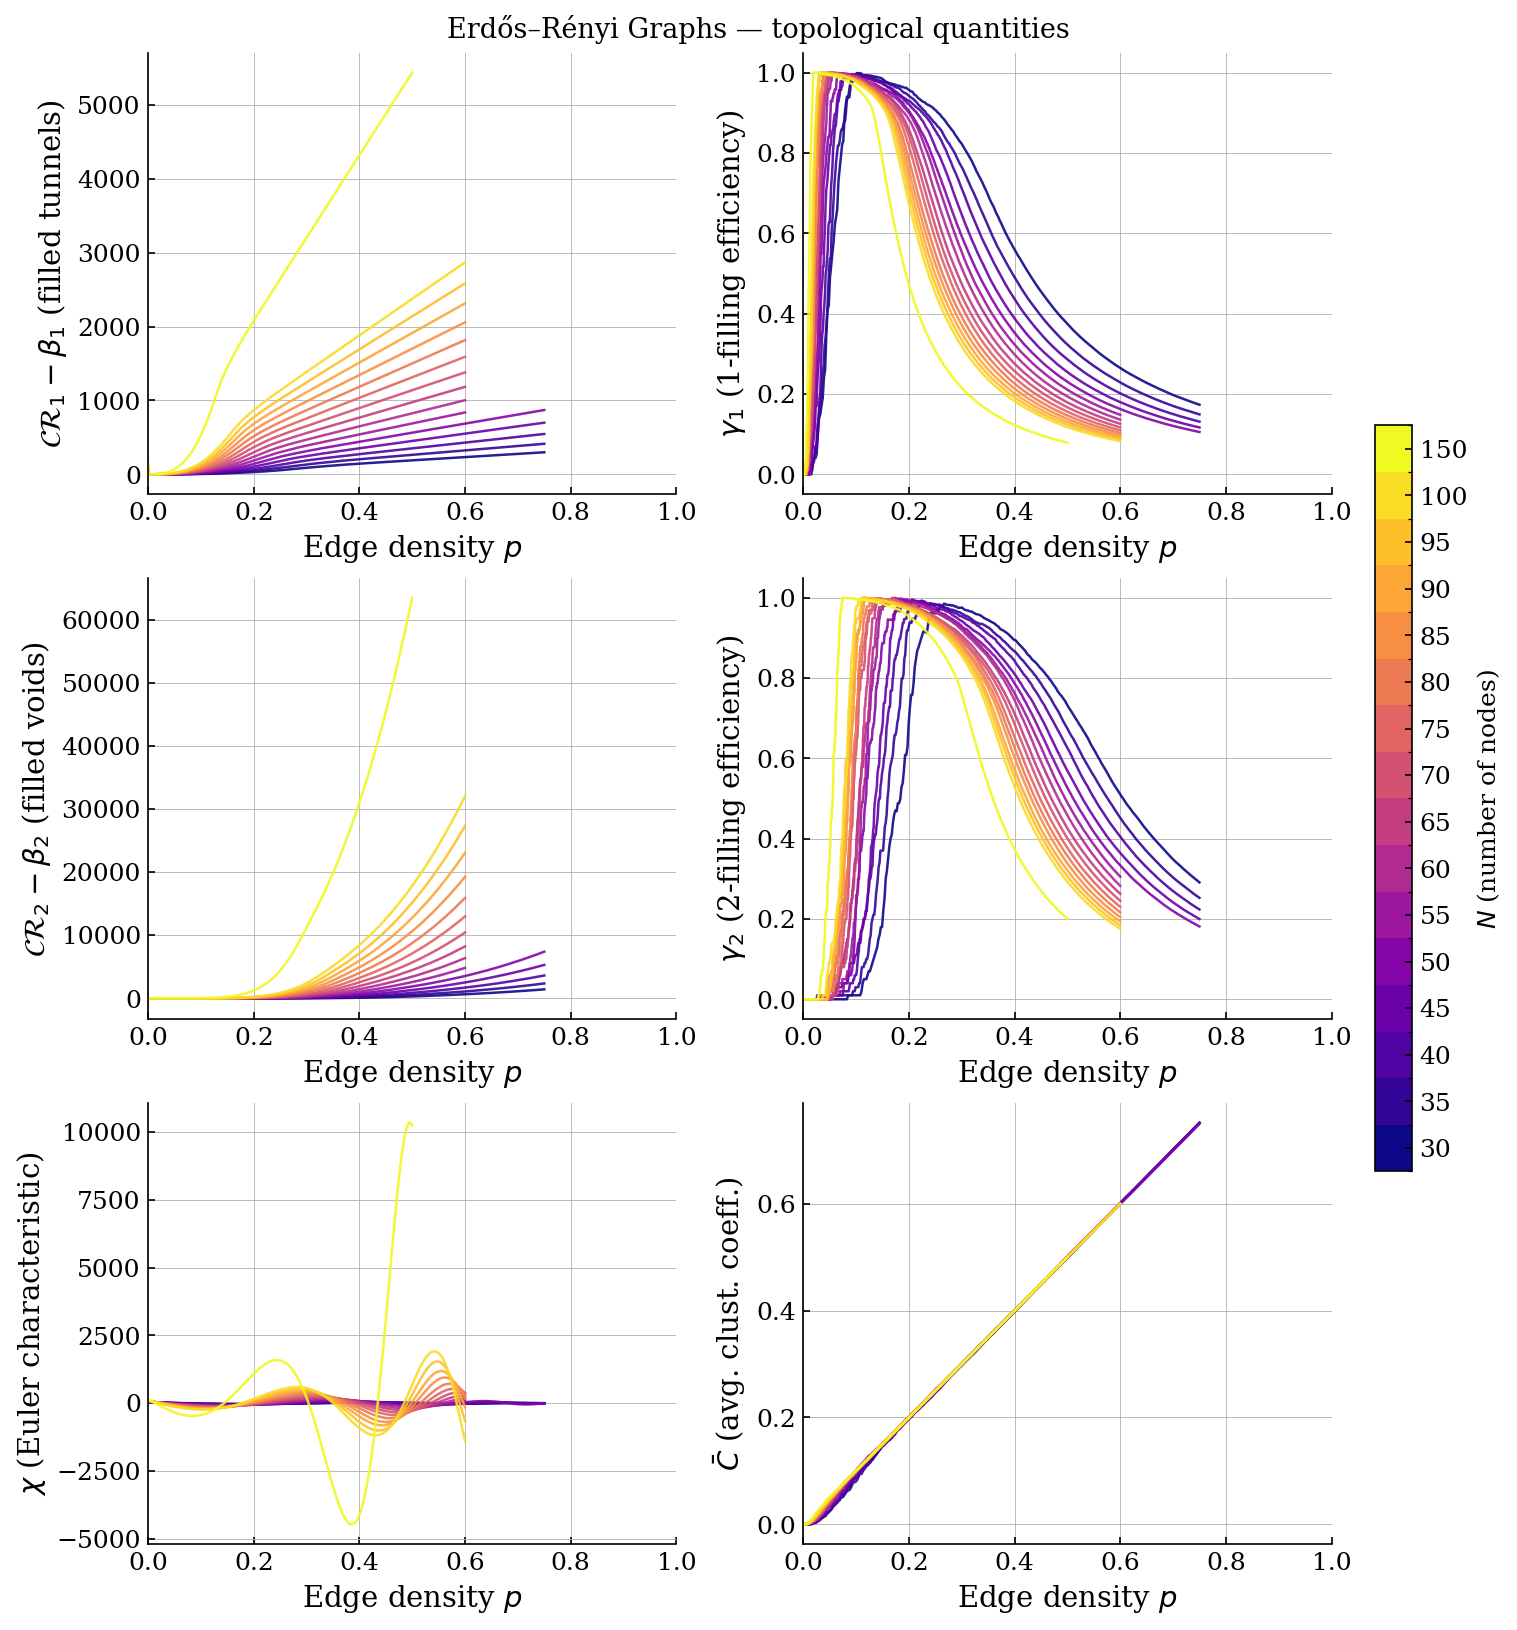

Saved: fig_ER_all_topology


In [5]:
NP_sorted = sorted(NP_combinations[5:], key=lambda x: x[0])
N_all     = [n for n, p in NP_sorted]

# Discrete colormap — one block per unique N value
N_unique    = list(dict.fromkeys(N_all))
n_k         = len(N_unique)
n_cmap_all  = cm.get_cmap('plasma', n_k)
n_boundaries = np.arange(n_k + 1) - 0.5
n_norm_all   = mcolors.BoundaryNorm(n_boundaries, ncolors=n_k)
n_colors_all = {n: n_cmap_all(i) for i, n in enumerate(N_unique)}

# ============================================================
# Figure 1: β0,β̃0 | β1,β̃1 | β2,β̃2
# ============================================================
draw_er_figure(
    data_er, n_colors_all, NP_sorted, fields, iterations, n_cmap_all, n_norm_all, n_k, N_unique,
    panel_layout = [
    (r'$\beta_0$ (connected components)',  r'$\tilde{\beta}_0=\beta_0/N$'),
    (r'$\beta_1$ (tunnels)',  r'$\tilde{\beta}_1=\beta_1/N_1$'),
    (r'$\beta_2$ (voids)',  r'$\tilde{\beta}_2=\beta_2/N_2$'),],
    suptitle    = r'Erdős–Rényi Graphs — Betti numbers',
    base_path = base_path_er,
    save_prefix = 'fig_ER_all_betti',
    shrink      = 0.5,)

# ============================================================
# Figure 2: CR1-β1,γ1 | CR2-β2,γ2 | χ,clusterC
# ============================================================
draw_er_figure(
    data_er, n_colors_all, NP_sorted, fields, iterations, n_cmap_all, n_norm_all, n_k, N_unique,
    panel_layout  = [(r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)',   r'$\gamma_1$ (1-filling efficiency)'),
                    (r'$\mathcal{CR}_2 - \beta_2$ (filled voids)',   r'$\gamma_2$ (2-filling efficiency)'),
                    (r'$\chi$ (Euler characteristic)',                         r'$\bar{C}$ (avg. clust. coeff.)')],
    suptitle    = r'Erdős–Rényi Graphs — topological quantities',
    base_path = base_path_er,
    save_prefix = 'fig_ER_all_topology',
    shrink      = 0.5,
)

## Plotting Euler characteristic against exact solution

/tmp/ipykernel_49880/3406657777.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  n_cmap_th  = cm.get_cmap('plasma')
/tmp/ipykernel_49880/3406657777.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  n_cmap_ov   = cm.get_cmap('plasma')


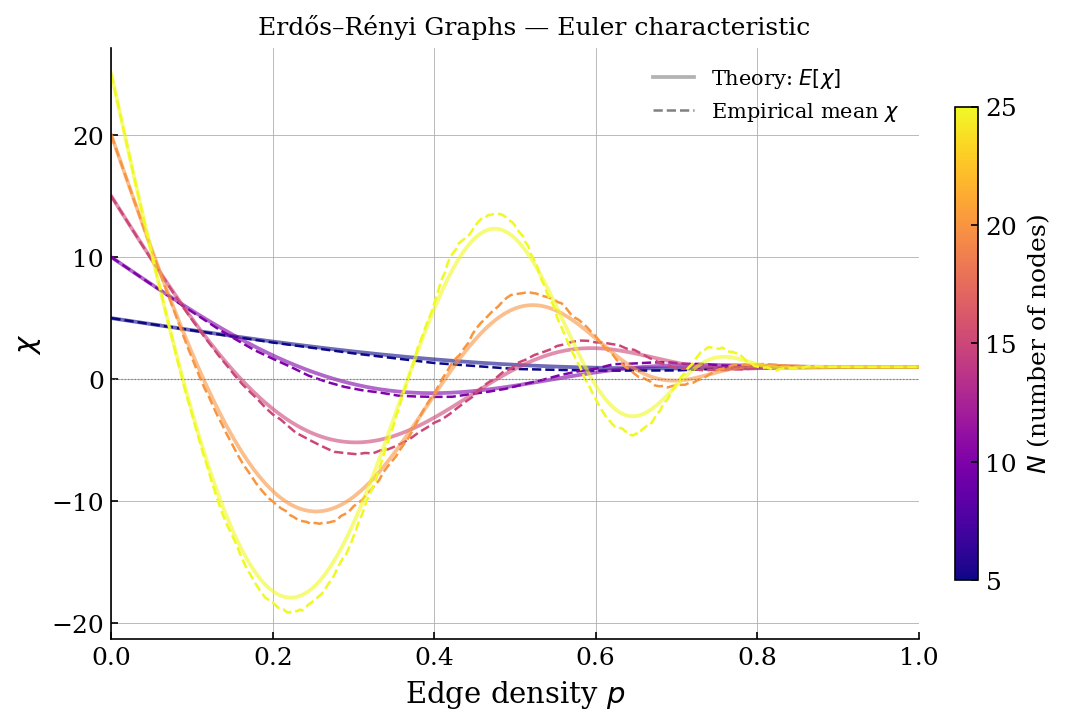

Saved: fig_ER_theory_vs_empirical


In [6]:
# N values to evaluate — can go much larger than TDA allows
N_theory = [50,100,200]
p_vals   = np.linspace(0, 1, 500)

n_cmap_th  = cm.get_cmap('plasma')
n_norm_th  = mcolors.Normalize(vmin=min(N_theory), vmax=max(N_theory))
n_colors_th = {n: n_cmap_th(n_norm_th(n)) for n in N_theory}

p_vals   = np.linspace(0, 1, 500)

# ============================================================
# Figure 3: Theory vs empirical Euler characteristic
# ============================================================
N_overlap = sorted(set(n for n, p in NP_combinations if p == 1))

n_cmap_ov   = cm.get_cmap('plasma')
n_norm_ov   = mcolors.Normalize(vmin=min(N_overlap), vmax=max(N_overlap))
n_colors_ov = {n: n_cmap_ov(n_norm_ov(n)) for n in N_overlap}

fig3, ax3 = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

for n in N_overlap:
    color = n_colors_ov[n]

    # Full theoretical Euler characteristic
    chi_full, _ = expected_euler(n, p_vals)
    ax3.plot(p_vals, chi_full, color=color, lw=1.8, linestyle='-', alpha=0.6)

    # Empirical mean — full chi computed from all simplex dimensions
    x_emp, mean_emp = get_mean_traj_er(data_er, n, 1, iterations, fields[r'$\chi$ (Euler characteristic)'])
    if x_emp is not None:
        ax3.plot(x_emp, mean_emp, color=color, lw=1.2, linestyle='--')

h_theory    = mlines.Line2D([], [], color='gray', lw=1.8, linestyle='-',
                             alpha=0.6, label=r'Theory: $E[\chi]$')
h_empirical = mlines.Line2D([], [], color='gray', lw=1.2, linestyle='--',
                             label=r'Empirical mean $\chi$')
ax3.legend(handles=[h_theory, h_empirical], frameon=False, fontsize=10)
ax3.axhline(y=0, color='gray', lw=0.6, linestyle=':')
ax3.set_xlabel(r'Edge density $p$')
ax3.set_ylabel(r'$\chi$')
ax3.set_xlim(0, 1)

sm3 = cm.ScalarMappable(cmap=n_cmap_ov, norm=n_norm_ov)
sm3.set_array([])
cbar3 = fig3.colorbar(sm3, ax=ax3, shrink=0.8, pad=0.02, location='right')
cbar3.set_label(r'$N$ (number of nodes)', fontsize=12)
cbar3.set_ticks(N_overlap)

fig3.suptitle(
    r'Erdős–Rényi Graphs — Euler characteristic',
    fontsize=12, y=1.04
)
fig3.savefig(base_path_er + 'fig_ER_theory_vs_empirical.pdf',
             dpi=300, bbox_inches='tight')
fig3.savefig(base_path_er + 'fig_ER_theory_vs_empirical.png',
             dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_ER_theory_vs_empirical')

## Loading Watts-Strogatz graph data

In [7]:
base_path_ws = 'WattsStrogatz/'

N_ws_graph  = [500]
K_ws_graph  = [4, 6, 8, 10, 12, 14, 16, 18]
iterations_ws_graph = list(range(1, 101))
num_cores   = 8

# Data format: [Betti, SimplexCounts, Euler, cycleR, clusterC, pathL]
WS_GRAPH_FIELDS = ['Betti', 'SimplexCounts', 'Euler', 'cycleR', 'clusterC', 'pathL']

all_params_ws_graph = list(product(N_ws_graph, K_ws_graph, iterations_ws_graph))

results_ws_graph = Parallel(n_jobs=num_cores, backend='loky')(
    delayed(load_single_ws)(n, k, iteration, base_path_ws)
    for n, k, iteration in tqdm(all_params_ws_graph, desc='Loading WS graph files')
)

# data_ws_graph[n][k][iteration] = [Betti, SimplexCounts, Euler, cycleR, clusterC, pathL]
data_ws_graph = {
    n: {k: {} for k in K_ws_graph}
    for n in N_ws_graph
}

missing_ws   = 0
corrupted_ws = 0
loaded_ws    = 0

for n, k, iteration, entry, status in results_ws_graph:
    data_ws_graph[n][k][iteration] = entry
    if status == 'ok':
        loaded_ws += 1
    elif status == 'missing':
        missing_ws += 1
    else:
        corrupted_ws += 1
        print(f'  n={n}, k={k}, iter={iteration}: {status}')

total_ws = len(all_params_ws_graph)
print(f'\nLoaded: {loaded_ws}/{total_ws}')
print(f'Missing: {missing_ws}, Corrupted: {corrupted_ws}')

Loading WS graph files:   0%|          | 0/800 [00:00<?, ?it/s]


Loaded: 800/800
Missing: 0, Corrupted: 0


## Plotting Watts-Strogatz Results

/tmp/ipykernel_49880/2770941490.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  k_cmap_ws   = cm.get_cmap('plasma', n_k_ws)


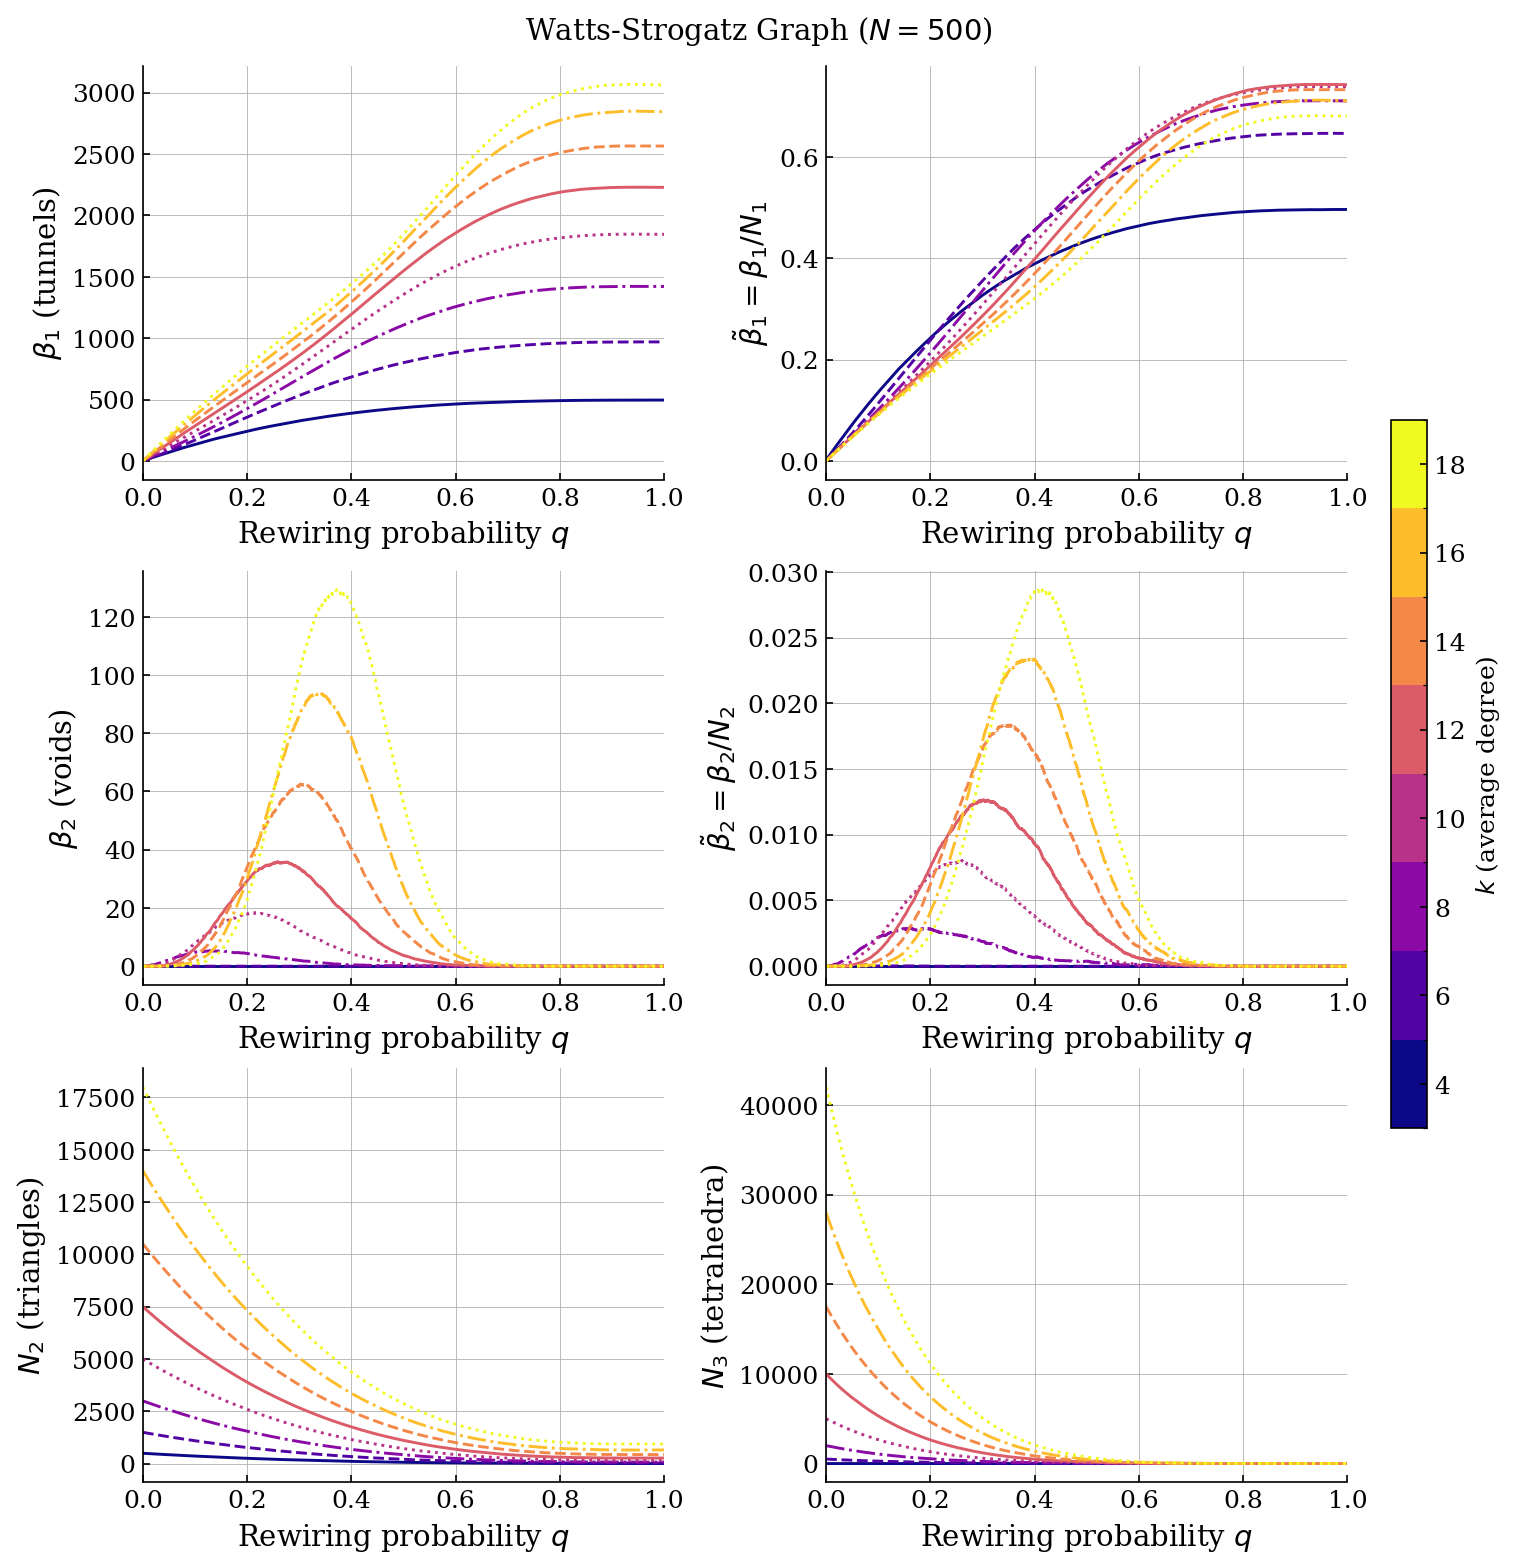

Saved: fig_WS_graph_homology


/tmp/ipykernel_49880/245365849.py:64: RuntimeWarning: invalid value encountered in divide
  (cR2_ws(e) - e[0][2].astype(float))


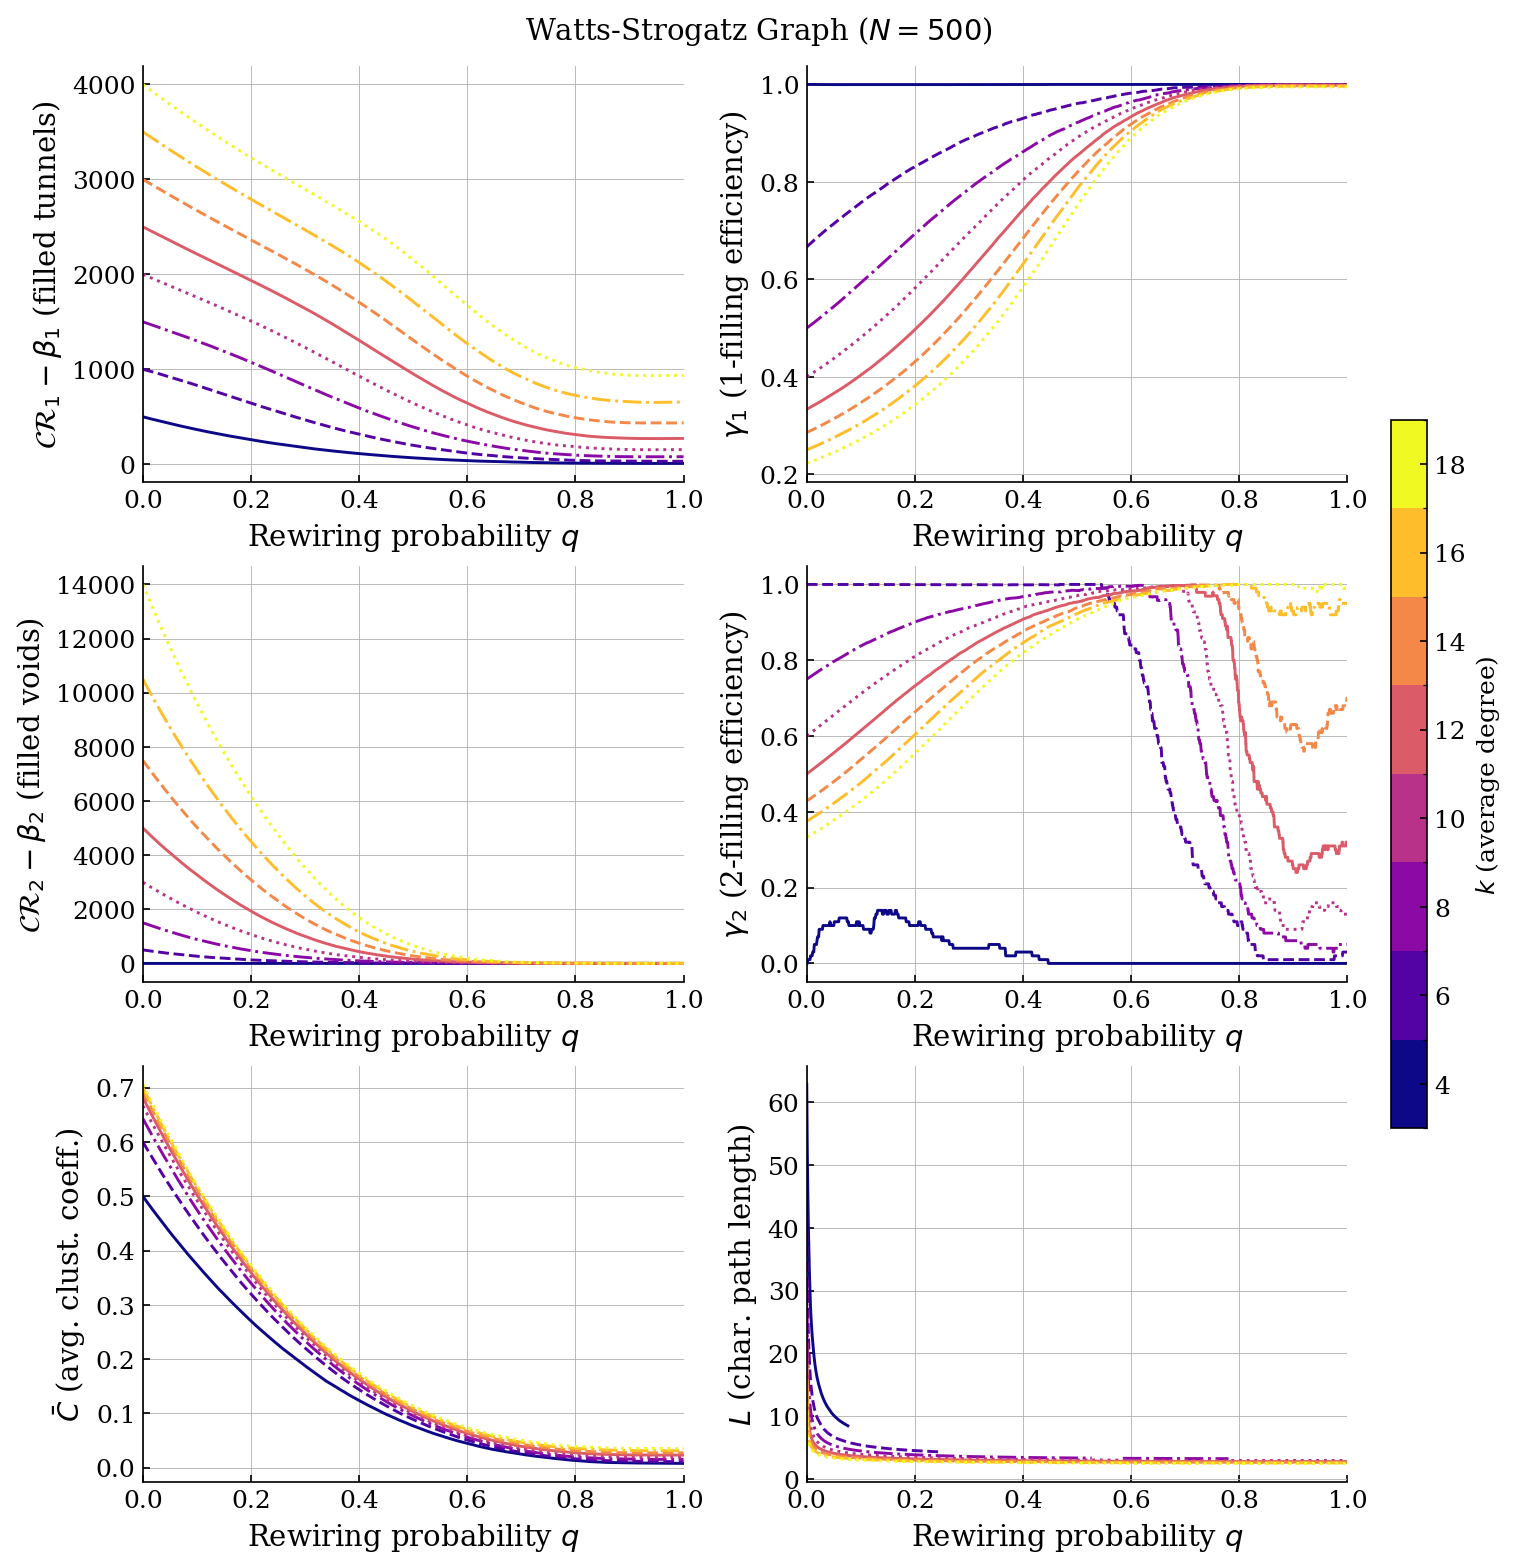

Saved: fig_WS_graph_cyclerank


In [8]:
n_plot        = 500

# ── discrete colormap over K_ws_graph ────────────────────────────────────────

n_k_ws      = len(K_ws_graph)
k_cmap_ws   = cm.get_cmap('plasma', n_k_ws)
k_colors_ws = {k: k_cmap_ws(i) for i, k in enumerate(K_ws_graph)}
linestyles  = ['-', '--', '-.', ':', '-', '--', '-.', ':']
k_ls_ws     = {k: linestyles[i] for i, k in enumerate(K_ws_graph)}

boundaries_ws = np.arange(n_k_ws + 1) - 0.5
norm_ws       = mcolors.BoundaryNorm(boundaries_ws, ncolors=n_k_ws)

# ── drawing function ──────────────────────────────────────────────────────────

suptitle_ws = rf'Watts-Strogatz Graph ($N={n_plot}$)'

# ── Figure 1: β1,β̃1 | β2,β̃2 | N2,N3  (3 rows × 2 cols) ────────────────────

draw_ws_figure(
    data_ws_graph, fields_ws, n_plot, k_cmap_ws, norm_ws, n_k_ws, K_ws_graph,
                   k_colors_ws, k_ls_ws, iterations_ws_graph,
    panel_layout = [r'$\beta_1$ (tunnels)',             r'$\tilde{\beta}_1=\beta_1/N_1$',
                    r'$\beta_2$ (voids)',             r'$\tilde{\beta}_2=\beta_2/N_2$',
                    r'$N_2$ (triangles)',                 r'$N_3$ (tetrahedra)'],
    nrows=3, ncols=2, figsize=(10, 10),
    suptitle    = suptitle_ws,
    base_path = base_path_ws,
    save_prefix = 'fig_WS_graph_homology',
    cbar_shrink = 0.5,
)

# ── Figure 2: CR1-β1,γ1 | CR2-β2,γ2 | C̄,L̄  (3 rows × 2 cols) ──────────────

draw_ws_figure(
    data_ws_graph, fields_ws, n_plot, k_cmap_ws, norm_ws, n_k_ws, K_ws_graph,
                   k_colors_ws, k_ls_ws, iterations_ws_graph,
    panel_layout = [r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)',  r'$\gamma_1$ (1-filling efficiency)',
                    r'$\mathcal{CR}_2 - \beta_2$ (filled voids)',  r'$\gamma_2$ (2-filling efficiency)',
                    r'$\bar{C}$ (avg. clust. coeff.)',                    r'$L$ (char. path length)'],
    nrows=3, ncols=2, figsize=(10, 10),
    suptitle    = suptitle_ws,
    base_path = base_path_ws,
    save_prefix = 'fig_WS_graph_cyclerank',
    cbar_shrink = 0.5,
)

## Loading for Watts-Strogatz scaling comparison

In [9]:
N_ws_scaling  = [50, 100, 200, 500, 1000, 2000]
K_ws_scaling  = [4, 6, 8, 10]
iterations_ws_scaling = list(range(1, 101))
num_cores     = 8


all_params_ws_scaling = list(product(
    N_ws_scaling, K_ws_scaling, iterations_ws_scaling
))

results_ws_scaling = Parallel(n_jobs=num_cores, backend='loky')(
    delayed(load_single_ws)(n, k, iteration, base_path_ws)
    for n, k, iteration in tqdm(all_params_ws_scaling,
                                 desc='Loading WS scaling files')
)

# data_ws_scaling[n][k][iteration] = entry
data_ws_scaling = { n: {k: {} for k in K_ws_scaling} for n in N_ws_scaling
}

missing_sc = 0; corrupted_sc = 0; loaded_sc = 0
for n, k, iteration, entry, status in results_ws_scaling:
    data_ws_scaling[n][k][iteration] = entry
    if status == 'ok':        loaded_sc   += 1
    elif status == 'missing': missing_sc  += 1
    else:
        corrupted_sc += 1
        print(f'  n={n}, k={k}, iter={iteration}: {status}')

print(f'\nLoaded: {loaded_sc}/{len(all_params_ws_scaling)}')
print(f'Missing: {missing_sc}, Corrupted: {corrupted_sc}')

Loading WS scaling files:   0%|          | 0/2400 [00:00<?, ?it/s]


Loaded: 2280/2400
Missing: 120, Corrupted: 0


## Plotting Watts-Strogatz scaling comparison

/tmp/ipykernel_49880/4243764079.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  k_cmap_sc   = cm.get_cmap('plasma', n_k_sc)
/tmp/ipykernel_49880/245365849.py:64: RuntimeWarning: invalid value encountered in divide
  (cR2_ws(e) - e[0][2].astype(float))
/tmp/ipykernel_49880/245365849.py:64: RuntimeWarning: invalid value encountered in divide
  (cR2_ws(e) - e[0][2].astype(float))
/tmp/ipykernel_49880/245365849.py:64: RuntimeWarning: invalid value encountered in divide
  (cR2_ws(e) - e[0][2].astype(float))


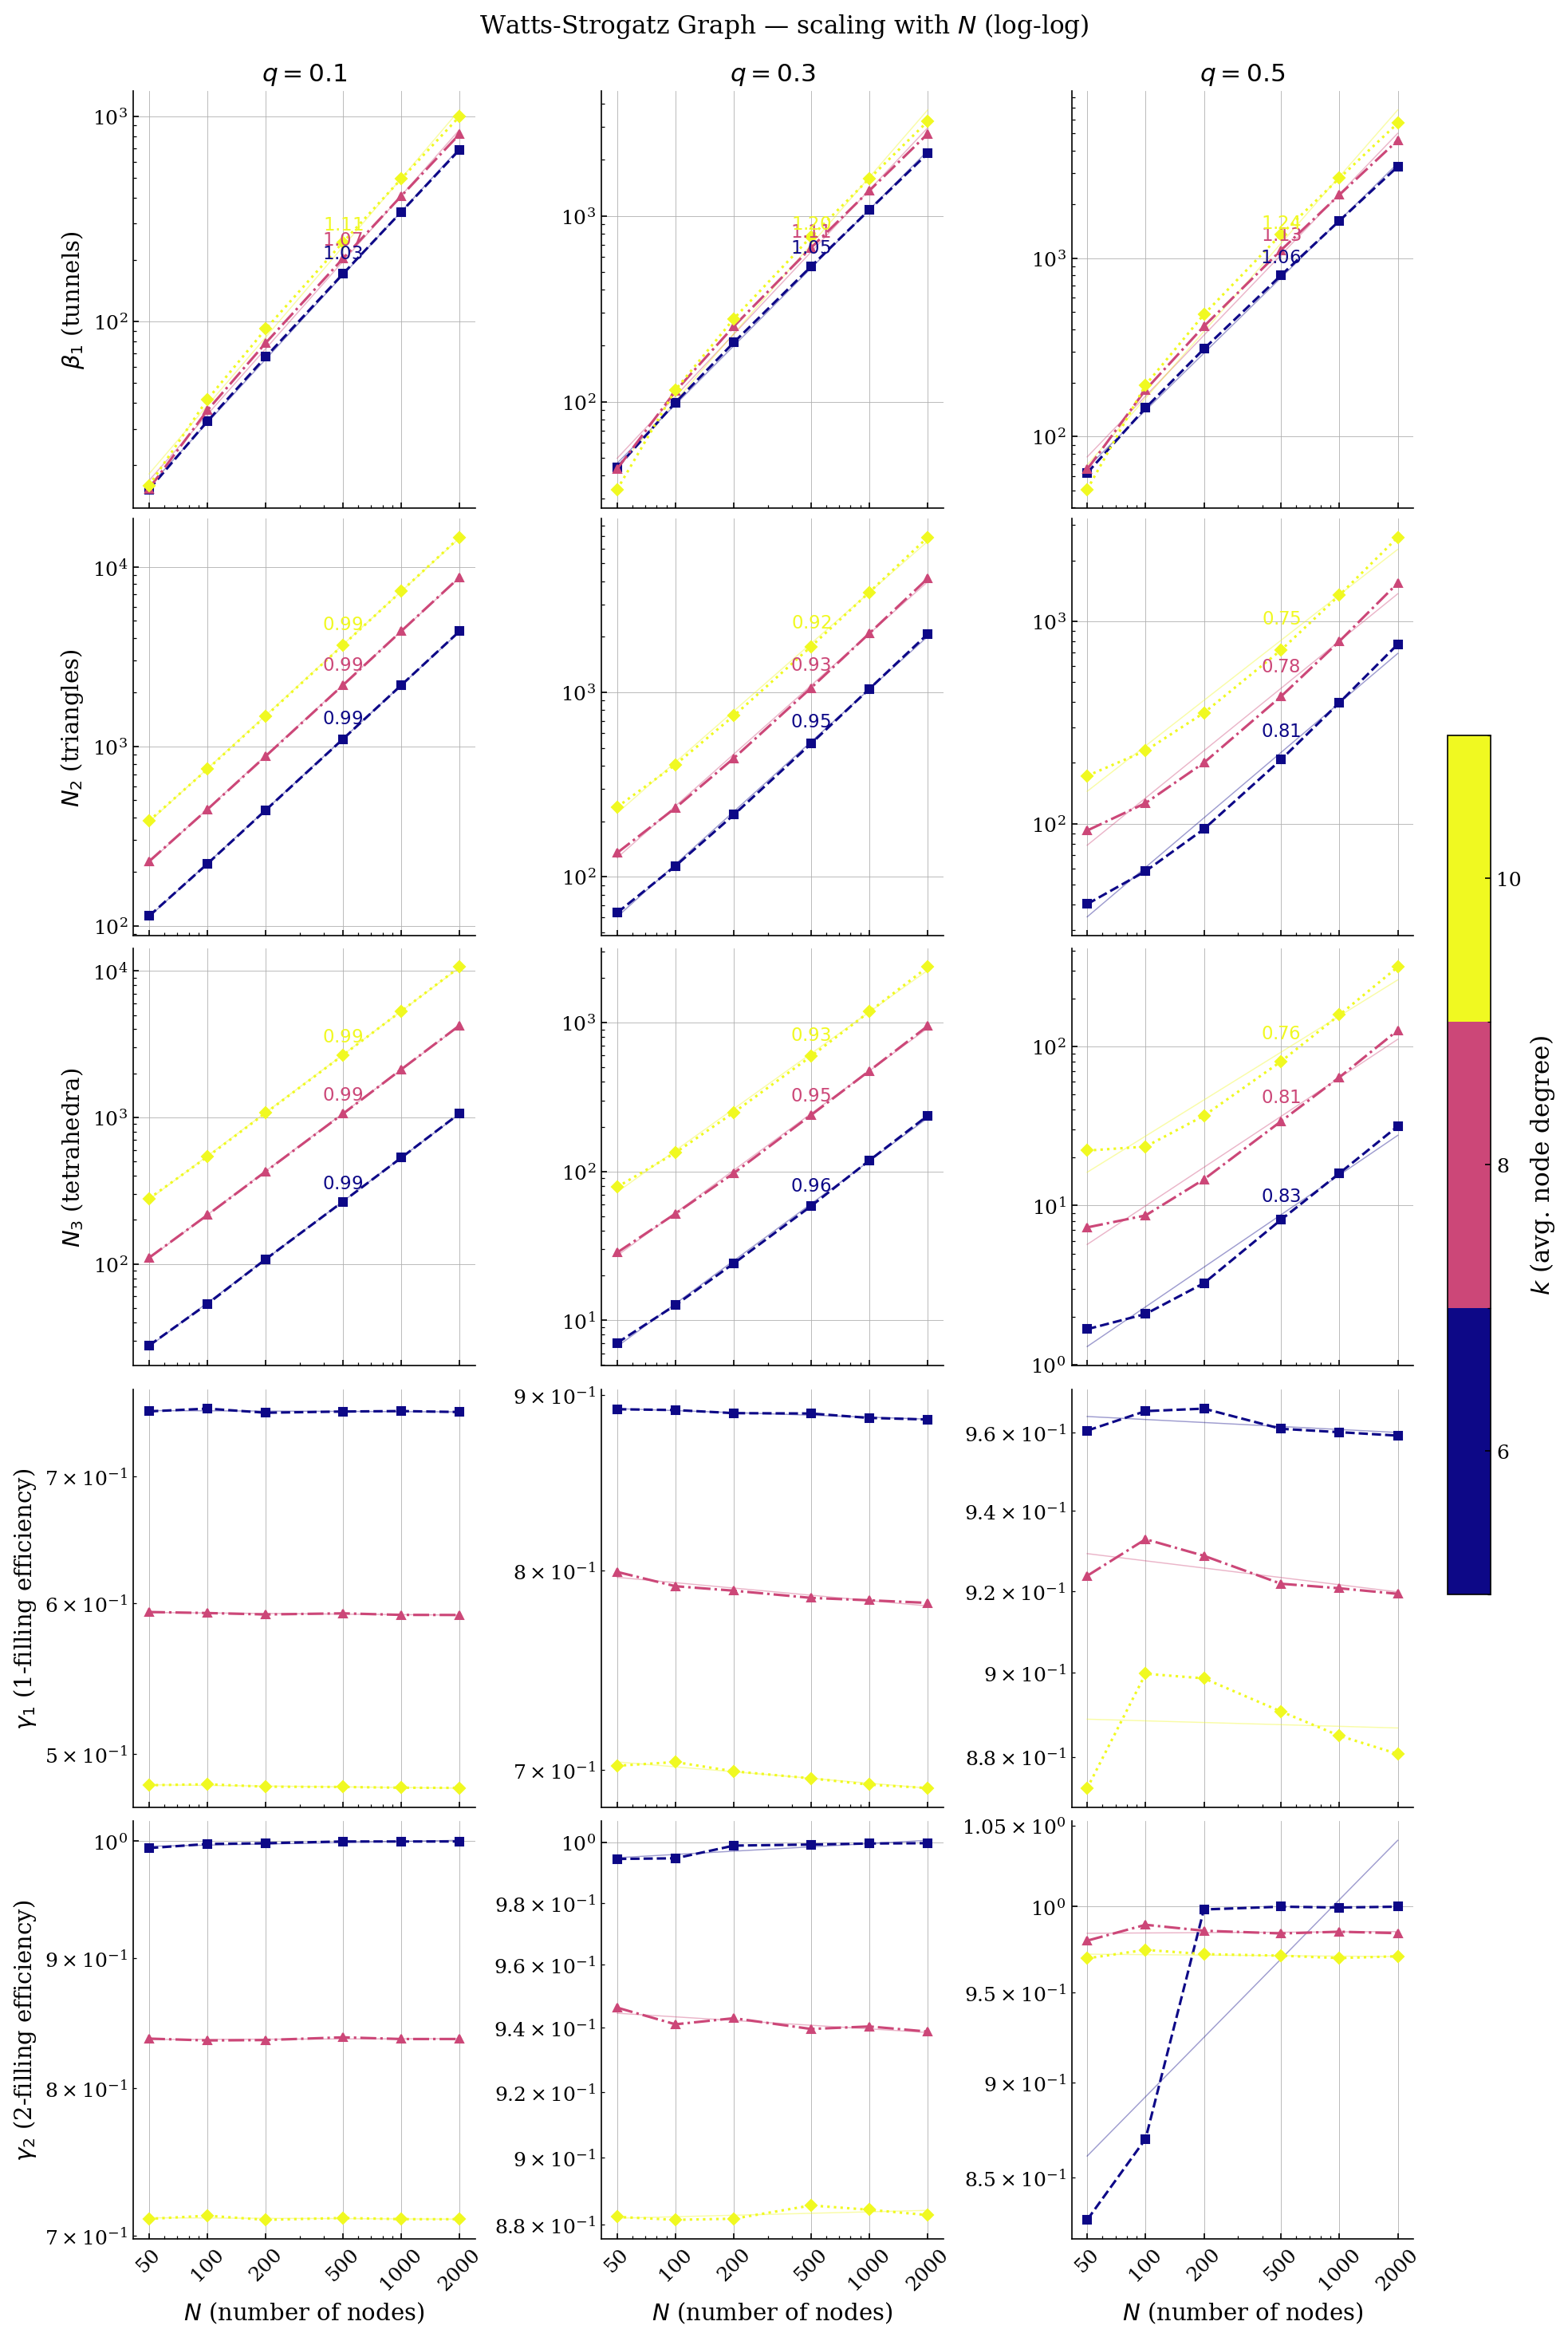

Saved: fig_WS_scaling_consolidated


In [10]:
# ============================================================
# Setup
# ============================================================
q_slices    = [0.1, 0.3, 0.5]
K_ws_scaling = [6, 8, 10]

n_k_sc      = len(K_ws_scaling)
k_cmap_sc   = cm.get_cmap('plasma', n_k_sc)
k_colors_sc = {k: k_cmap_sc(i) for i, k in enumerate(K_ws_scaling)}
k_markers   = {4: 'o', 6: 's', 8: '^', 10: 'D'}
k_ls_sc     = {4: '-', 6: '--', 8: '-.', 10: ':'}

k_boundaries_sc = np.arange(n_k_sc + 1) - 0.5
k_norm_sc       = mcolors.BoundaryNorm(k_boundaries_sc, ncolors=n_k_sc)

n_arr = np.array(N_ws_scaling, dtype=float)

panel_labels = [r'$\beta_1$ (tunnels)', r'$N_2$ (triangles)', r'$N_3$ (tetrahedra)',
                r'$\gamma_1$ (1-filling efficiency)', r'$\gamma_2$ (2-filling efficiency)']

# ============================================================
# Single consolidated 5 x 3 figure
# ============================================================
n_rows = len(panel_labels)   # 5 quantities
n_cols = len(q_slices)       # 3 q values

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(13, 3.8 * n_rows),
                          constrained_layout=True)

for row_idx, label in enumerate(panel_labels):
    field_fn = fields_ws[label]

    for col_idx, q in enumerate(q_slices):
        ax = axes[row_idx][col_idx]

        for k in K_ws_scaling:
            vals = np.array([
                get_value_at_q(data_ws_scaling, iterations_ws_scaling, n, k, field_fn, q)
                for n in N_ws_scaling])

            valid = np.isfinite(vals) & (vals > 0)
            if valid.sum() < 2:
                continue

            ax.loglog(n_arr[valid], vals[valid], marker=k_markers[k],
                      linestyle=k_ls_sc[k], color=k_colors_sc[k],
                      lw=1.5, markersize=5, zorder=3)

            # Power law fit — annotate exponent if fit is reliable
            if valid.sum() >= 3:
                coeffs   = np.polyfit(np.log(n_arr[valid]),
                                      np.log(vals[valid]), 1)
                exponent = coeffs[0]
                fit_line = np.exp(coeffs[1]) * n_arr[valid] ** exponent

                ax.loglog(n_arr[valid], fit_line, linestyle='-',
                          color=k_colors_sc[k], lw=0.7, alpha=0.4, zorder=2)

                # Only annotate if exponent is meaningfully non-zero
                if abs(exponent) > 0.5:
                    # Place label at the midpoint of the fit range
                    mid_idx  = len(n_arr[valid]) // 2
                    x_pos    = n_arr[valid][mid_idx]
                    y_pos    = fit_line[mid_idx]
                    # Offset label slightly above the line
                    ax.text(x_pos, y_pos * 1.15, rf'${exponent:.2f}$', fontsize=11,
                            color=k_colors_sc[k], ha='center', va='bottom', zorder=4)

        # Column titles on top row only
        if row_idx == 0:
            ax.set_title(rf'$q = {q}$', fontsize=15, pad=6)

        # y-axis label on left column only
        ax.set_ylabel(label if col_idx == 0 else '')

        # x-axis label on bottom row only
        if row_idx == n_rows - 1:
            ax.set_xlabel(r'$N$ (number of nodes)')
        else:
            ax.tick_params(labelbottom=False)

        ax.set_xticks(N_ws_scaling)
        ax.set_xticklabels(
            [str(n) for n in N_ws_scaling] if row_idx == n_rows - 1
            else [], rotation=45
        )

# Colorbar
sm = cm.ScalarMappable(cmap=k_cmap_sc, norm=k_norm_sc)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:, :], shrink=0.4, pad=0.02,
                     location='right', ticks=np.arange(n_k_sc))
cbar.set_ticklabels([str(k) for k in K_ws_scaling])
cbar.set_label(r'$k$ (avg. node degree)', fontsize=15)

fig.suptitle(
    r'Watts-Strogatz Graph — scaling with $N$ (log-log)',
    fontsize=15, y=1.02
)

fig.savefig(base_path_ws + 'fig_WS_scaling_consolidated.pdf',
            dpi=300, bbox_inches='tight')
fig.savefig(base_path_ws + 'fig_WS_scaling_consolidated.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_WS_scaling_consolidated')

## Loading Barabasi-Albert results

In [11]:
base_path_ba  = 'BarabasiAlbert/'
N          = 10000
K          = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
iterations = list(range(1, 101))
num_cores  = 8

# Build full parameter list
all_params = list(product(K, iterations))

# Parallel load — each worker handles one (k, iteration) pair
results = Parallel(n_jobs=num_cores, backend='loky')(
    delayed(load_single_ba)(N, k, iteration, base_path_ba)
    for k, iteration in tqdm(all_params, desc='Loading files')
)

# Assemble into indexed data structure
data_ba      = {k: {} for k in K}
missing   = 0
corrupted = 0
loaded    = 0

for k, iteration, entry, status in results:
    data_ba[k][iteration] = entry
    if status == 'ok':
        loaded += 1
    elif status == 'missing':
        missing += 1
    else:
        corrupted += 1
        print(f'  k={k}, iter={iteration}: {status}')

print(f'\nLoaded: {loaded} / {len(all_params)}')
print(f'Missing: {missing}, Corrupted: {corrupted}')

Loading files:   0%|          | 0/1100 [00:00<?, ?it/s]


Loaded: 1100 / 1100
Missing: 0, Corrupted: 0


## Plotting Barabasi-Albert trajectories

/tmp/ipykernel_49880/4194326990.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  k_cmap   = cm.get_cmap('plasma', n_k)
/tmp/ipykernel_49880/245365849.py:19: RuntimeWarning: invalid value encountered in divide
  e[0][2] / sc_col(e, 2), 0.0),


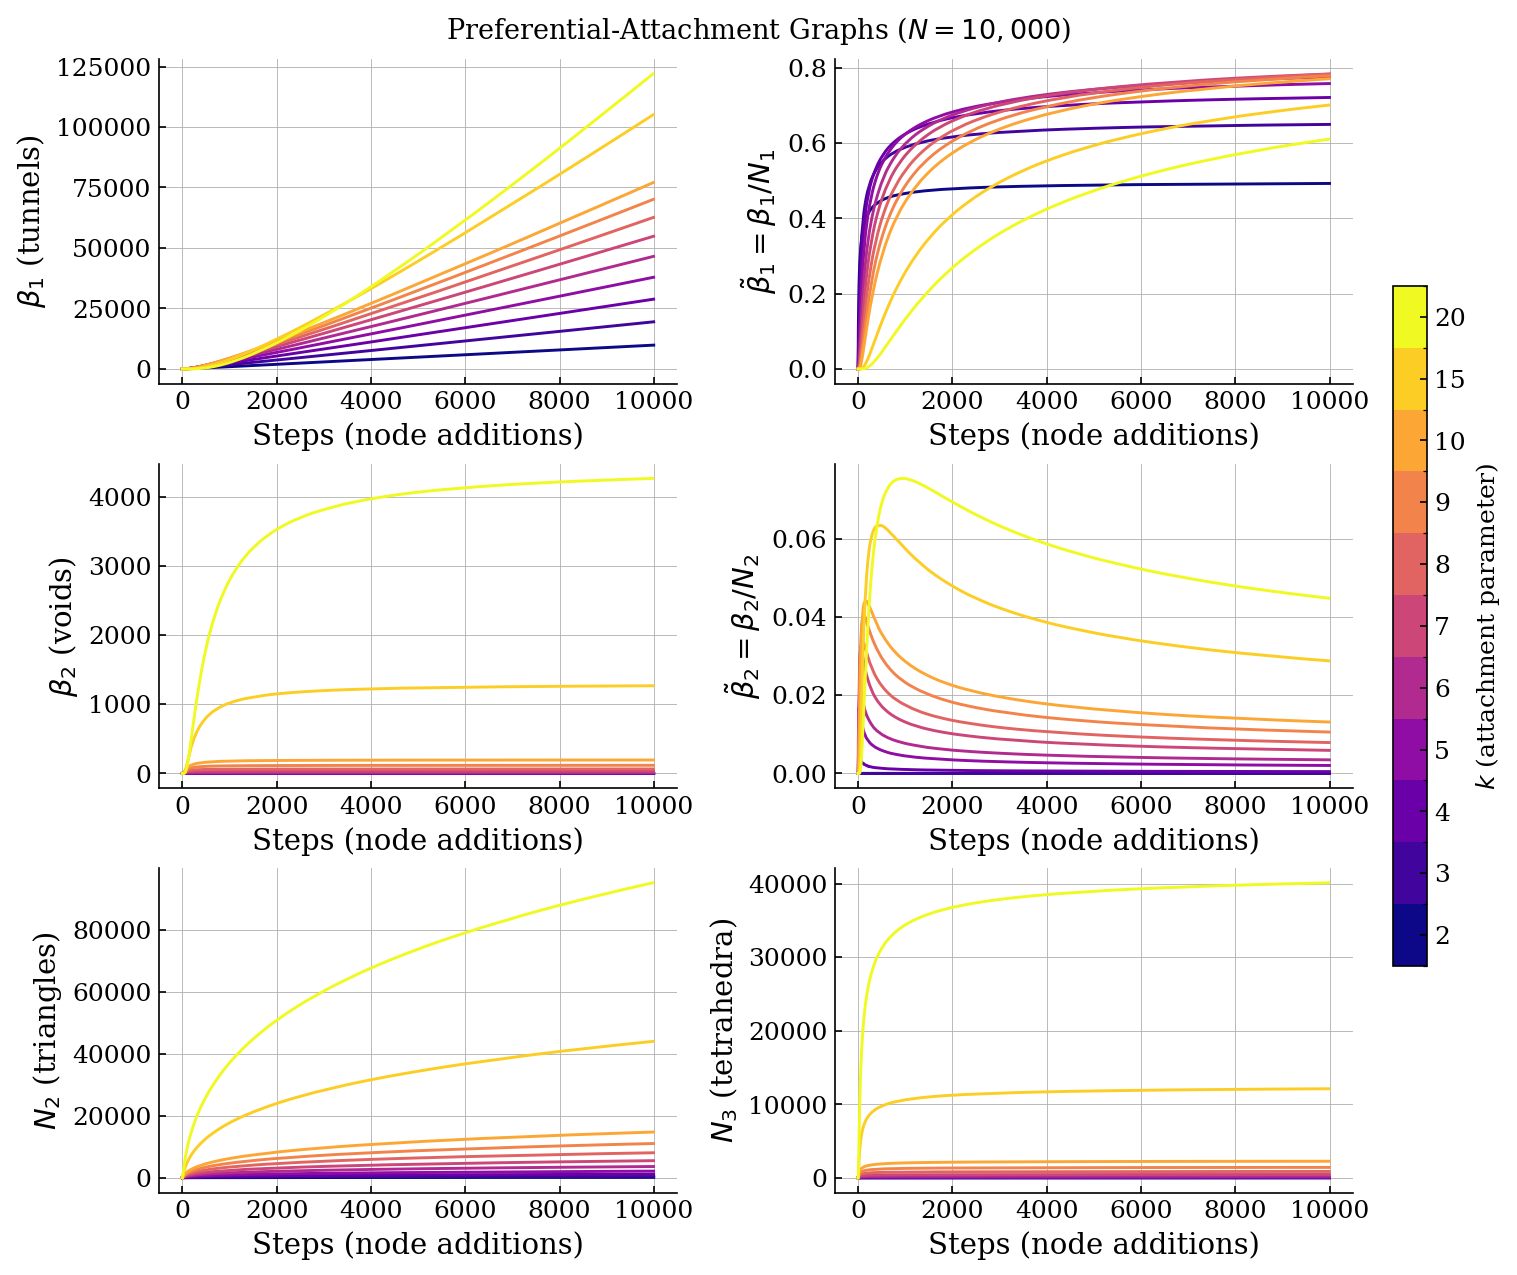

Saved: fig_PA_trajectories


In [12]:
# Discrete colormap — one solid block per k value
n_k      = len(K)
k_cmap   = cm.get_cmap('plasma', n_k)
k_colors = {k: k_cmap(i) for i, k in enumerate(K)}

# BoundaryNorm maps index i to block i, with boundaries at half-integers
boundaries = np.arange(n_k + 1) - 0.5
norm       = mcolors.BoundaryNorm(boundaries, ncolors=n_k)

# ============================================================
# Figure 1: β1, β̃1 | β2, β̃2 | N2, N3
# ============================================================
panel_layout_1 = [
    (r'$\beta_1$ (tunnels)',       r'$\tilde{\beta}_1=\beta_1/N_1$'),
    (r'$\beta_2$ (voids)',       r'$\tilde{\beta}_2=\beta_2/N_2$'),
    (r'$N_2$ (triangles)',           r'$N_3$ (tetrahedra)'),
]

n_rows = len(panel_layout_1)
n_cols = 2

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(10, 2.7 * n_rows), constrained_layout=True)

for row_idx, (left_label, right_label) in enumerate(panel_layout_1):
    is_bottom = (row_idx == n_rows - 1)
    for col_idx, label in enumerate([left_label, right_label]):
        ax       = axes1[row_idx][col_idx]
        field_fn = fields[label]

        for k in K:

            trajs = get_trajectories(data_ba, k, iterations, field_fn)
            if not trajs:
                continue
            max_len  = max(len(t) for t in trajs)
            x_common = np.arange(max_len)
            interp   = np.array([
                np.interp(x_common, np.arange(len(t)), t)
                for t in trajs
            ])
            ax.plot(x_common, interp.mean(axis=0),
                    color=k_colors[k], lw=1.4)

        ax.set_ylabel(label)
        ax.set_xlabel('Steps (node additions)')


add_discrete_colorbar_pa(fig1, axes1[:, :], k_cmap, norm, n_k, K)
fig1.suptitle(rf'Preferential-Attachment Graphs ($N = {N:,}$)', fontsize=13, y=1.03)
fig1.savefig(base_path_ba + 'fig_PA_trajectories.pdf', dpi=300, bbox_inches='tight')
fig1.savefig(base_path_ba + 'fig_PA_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_PA_trajectories')

## Loading random-attachment results

In [13]:
base_path_ra  = 'RandomAttachment/'
N          = 10000
K          = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
iterations = list(range(1, 101))
num_cores  = 8

all_params = list(product(K, iterations))

results = Parallel(n_jobs=num_cores, backend='loky')(
    delayed(load_single_ra)(N, k, iteration, base_path_ra)
    for k, iteration in tqdm(all_params, desc='Loading RA files')
)

data_ra   = {k: {} for k in K}
missing   = 0
missing_list = []
corrupted = 0
loaded    = 0

for k, iteration, entry, status in results:
    data_ra[k][iteration] = entry
    if status == 'ok':
        loaded += 1
    elif status == 'missing':
        missing += 1
        filename = os.path.join(base_path_ra,f'RA_{N}_{k}_{iteration}.pkl')
        missing_list.append(filename)
    else:
        corrupted += 1
        print(f'  k={k}, iter={iteration}: {status}')

print(f'\nLoaded: {loaded} / {len(all_params)}')
print(f'Missing: {missing}, Corrupted: {corrupted}')

Loading RA files:   0%|          | 0/1100 [00:00<?, ?it/s]


Loaded: 1100 / 1100
Missing: 0, Corrupted: 0


## Plotting random-attachment trajectories

/tmp/ipykernel_49880/1922894492.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  k_cmap_ra   = cm.get_cmap('plasma', n_k_ra)
/tmp/ipykernel_49880/245365849.py:19: RuntimeWarning: invalid value encountered in divide
  e[0][2] / sc_col(e, 2), 0.0),


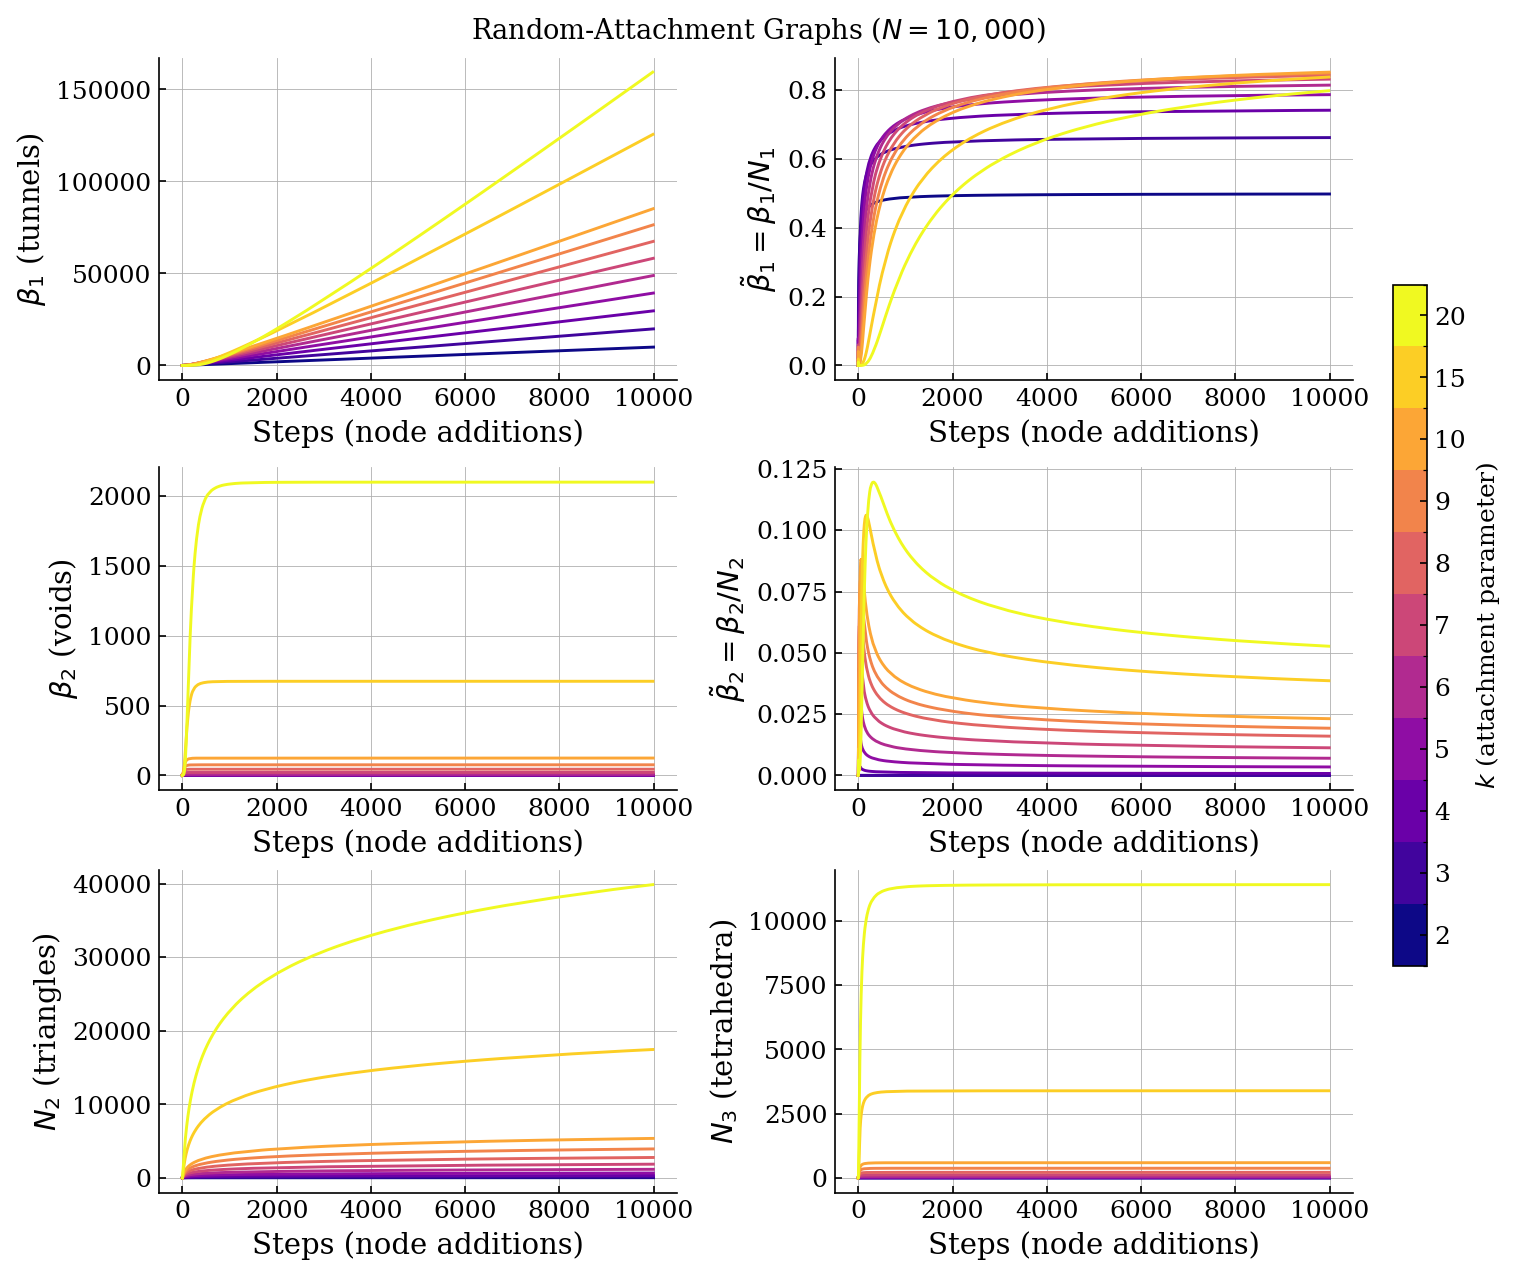

Saved: fig_RA_trajectories


In [14]:
# ============================================================
# RA-specific parameters
# ============================================================
K_ra_plot      = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
iterations_ra  = list(range(1, 101))

# Discrete colormap over K_ra_plot
n_k_ra      = len(K_ra_plot)
k_cmap_ra   = cm.get_cmap('plasma', n_k_ra)
k_colors_ra = {k: k_cmap_ra(i) for i, k in enumerate(K_ra_plot)}

boundaries_ra = np.arange(n_k_ra + 1) - 0.5
norm_ra       = mcolors.BoundaryNorm(boundaries_ra, ncolors=n_k_ra)

# ============================================================
# Figure 1: β1, β̃1 | β2, β̃2 | N2, N3
# ============================================================
panel_layout_ra_1 = [
    (r'$\beta_1$ (tunnels)',       r'$\tilde{\beta}_1=\beta_1/N_1$'),
    (r'$\beta_2$ (voids)',       r'$\tilde{\beta}_2=\beta_2/N_2$'),
    (r'$N_2$ (triangles)',           r'$N_3$ (tetrahedra)'),
]

n_rows = len(panel_layout_ra_1)
n_cols = 2

fig1, axes1 = plt.subplots(n_rows, n_cols,
                             figsize=(10, 2.7 * n_rows),
                             constrained_layout=True)

for row_idx, (left_label, right_label) in enumerate(panel_layout_ra_1):
    is_bottom = (row_idx == n_rows - 1)
    for col_idx, label in enumerate([left_label, right_label]):
        ax       = axes1[row_idx][col_idx]
        field_fn = fields[label]

        for k in K_ra_plot:
            trajs = get_trajectories(data_ra, k, iterations_ra, field_fn)
            if not trajs:
                continue
            max_len  = max(len(t) for t in trajs)
            x_common = np.arange(max_len)
            interp   = np.array([np.interp(x_common, np.arange(len(t)), t)
                for t in trajs])
            ax.plot(x_common, interp.mean(axis=0),
                    color=k_colors_ra[k], lw=1.4)

        ax.set_ylabel(label)
        ax.set_xlabel('Steps (node additions)')

add_discrete_colorbar_pa(fig1, axes1[:, :], k_cmap_ra, norm_ra, n_k_ra, K_ra_plot)
fig1.suptitle(rf'Random-Attachment Graphs ($N = {N:,}$)', fontsize=13, y=1.03)
fig1.savefig(base_path_ra + 'fig_RA_trajectories.pdf', dpi=300, bbox_inches='tight')
fig1.savefig(base_path_ra + 'fig_RA_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_RA_trajectories')

## Plotting PA vs RA trajectory comparisons

/tmp/ipykernel_49880/795486660.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_all = cm.get_cmap('plasma', n_k_all)
/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: divide by zero encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: invalid value encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:35: RuntimeWarning: divide by zero encountered in divide
  (cR2(e) - e[0][2].astype(float))
/tmp/ipykernel_49880/245365849.py:35: RuntimeWarning: invalid value encountered in divide
  (cR2(e) - e[0][2].astype(float))


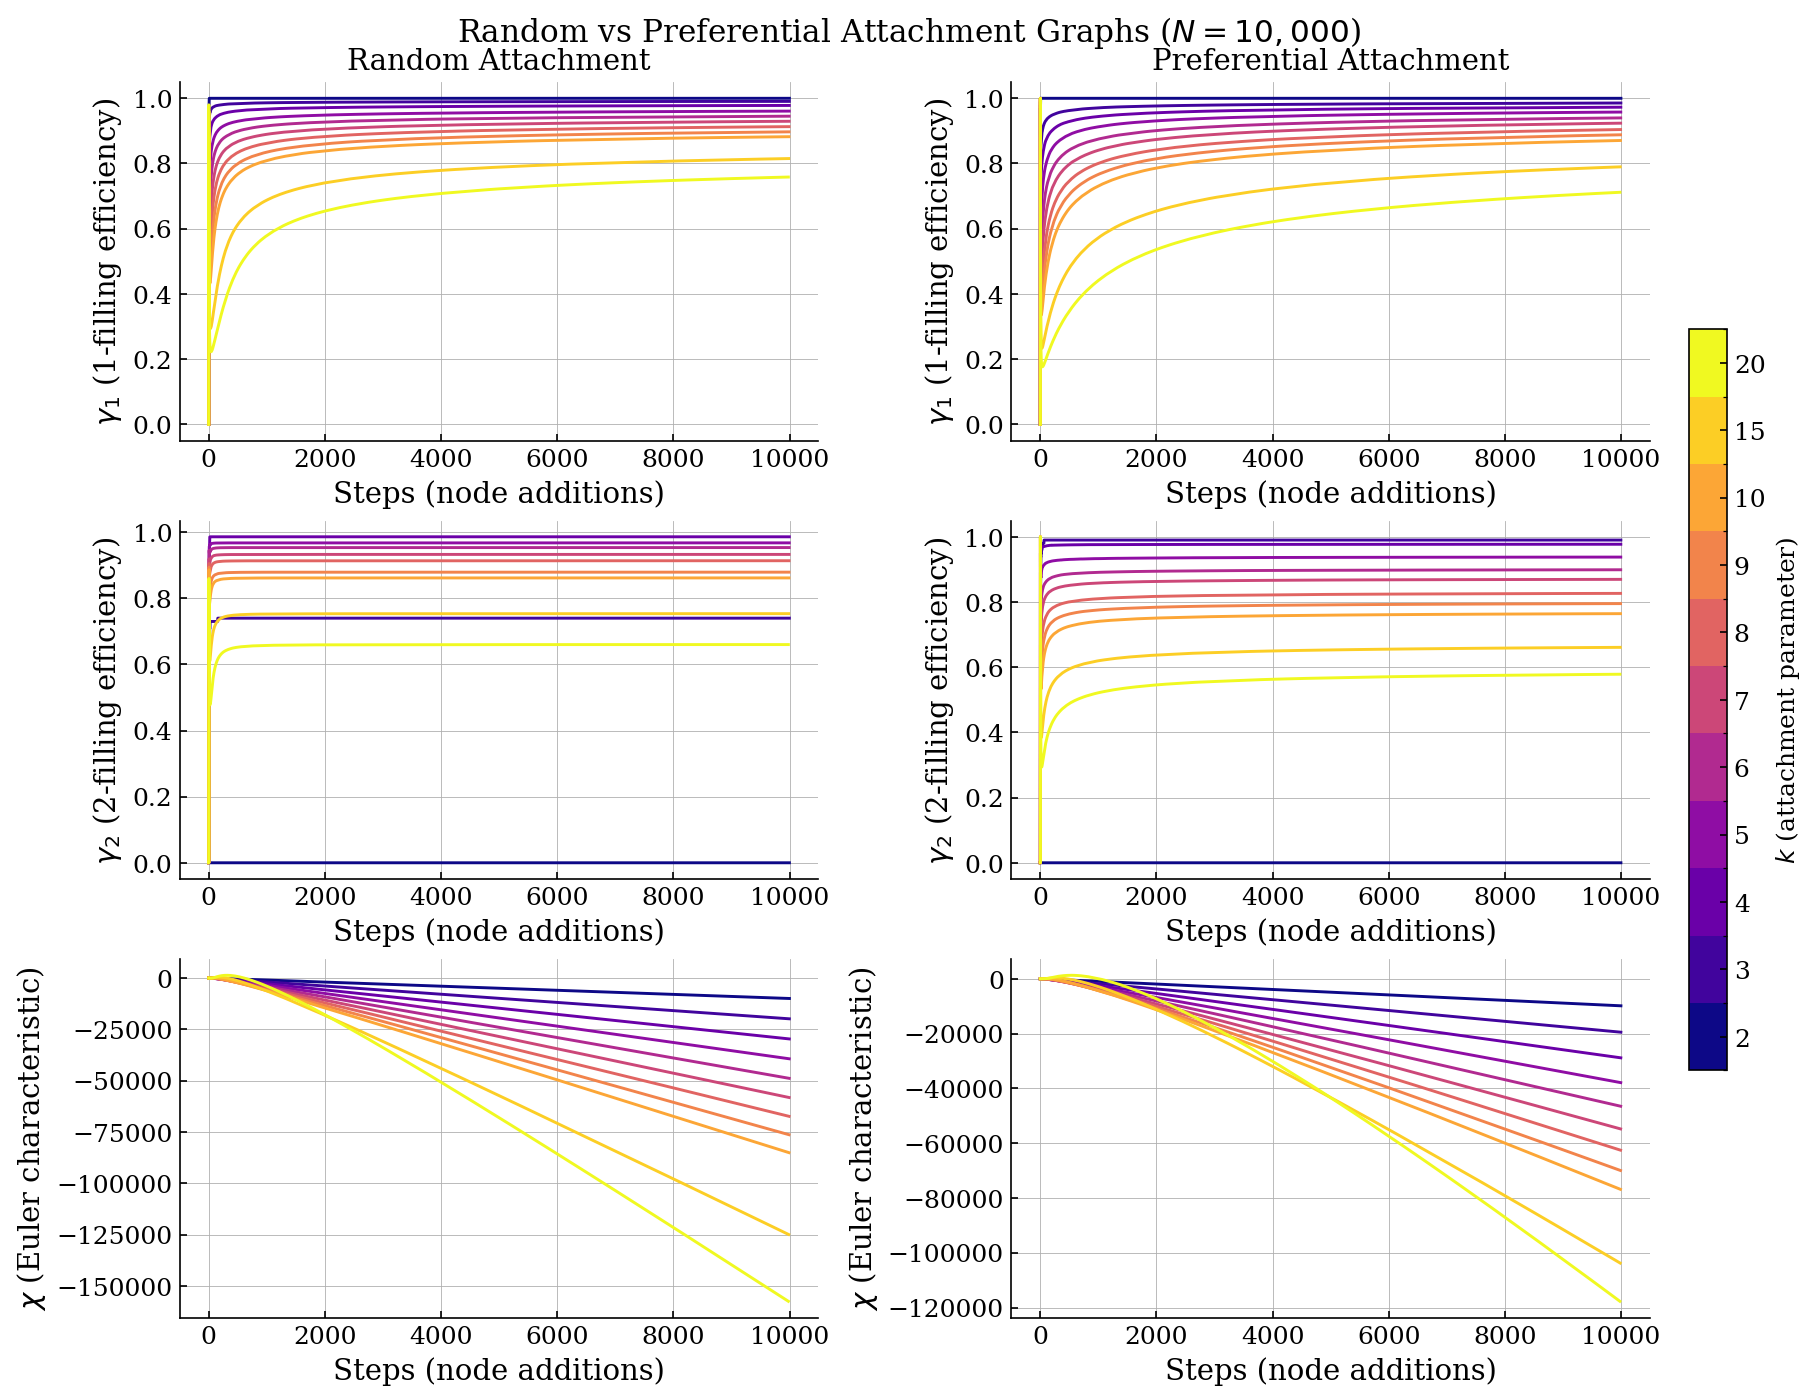

Saved: fig_RA_PA_comparison


In [15]:
# ── layout ────────────────────────────────────────────────────────────────────
# Rows: gamma1, gamma2, chi
# Cols: RA (left), PA (right)

row_labels  = [r'$\gamma_1$ (1-filling efficiency)', r'$\gamma_2$ (2-filling efficiency)', r'$\chi$ (Euler characteristic)']
col_titles  = ['Random Attachment', 'Preferential Attachment']

K_all    = sorted(set(K_ra_plot) | set(K))
n_k_all  = len(K_all)
cmap_all = cm.get_cmap('plasma', n_k_all)
colors_all     = {k: cmap_all(i) for i, k in enumerate(K_all)}
boundaries_all = np.arange(n_k_all + 1) - 0.5
norm_all       = mcolors.BoundaryNorm(boundaries_all, ncolors=n_k_all)

# ── figure ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(12, 9), constrained_layout=True)

for row, label in enumerate(row_labels):
    field_fn = fields[label]

    # ── left column: RA ───────────────────────────────────────────────────────
    ax = axes[row, 0]
    for k in K_ra_plot:
        trajs = get_trajectories(data_ra, k, iterations_ra, field_fn)
        x, mean = mean_traj(trajs)
        if x is None:
            continue
        ax.plot(x, mean, color=colors_all[k], lw=1.4)
    ax.set_ylabel(label)
    ax.set_xlabel('Steps (node additions)')

    # ── right column: PA ──────────────────────────────────────────────────────
    ax = axes[row, 1]
    for k in K:
        trajs = get_trajectories(data_ba, k, iterations, field_fn)
        x, mean = mean_traj(trajs)
        if x is None:
            continue
        ax.plot(x, mean, color=colors_all[k], lw=1.4)
    ax.set_ylabel(label)
    ax.set_xlabel('Steps (node additions)')

# column titles
for ax, title in zip(axes[0, :], col_titles):
    ax.set_title(title, pad=6)

add_discrete_colorbar_pa(fig, axes, cmap_all, norm_all, n_k_all, K_all)

fig.suptitle(rf'Random vs Preferential Attachment Graphs ($N = {N:,}$)',
             fontsize=15, y=1.02)
fig.savefig(base_path_ba + 'fig_RA_PA_comparison.pdf',
            dpi=300, bbox_inches='tight')
fig.savefig(base_path_ba + 'fig_RA_PA_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_RA_PA_comparison')

## Plotting PA vs RA terminal results

/tmp/ipykernel_49880/245365849.py:19: RuntimeWarning: invalid value encountered in divide
  e[0][2] / sc_col(e, 2), 0.0),


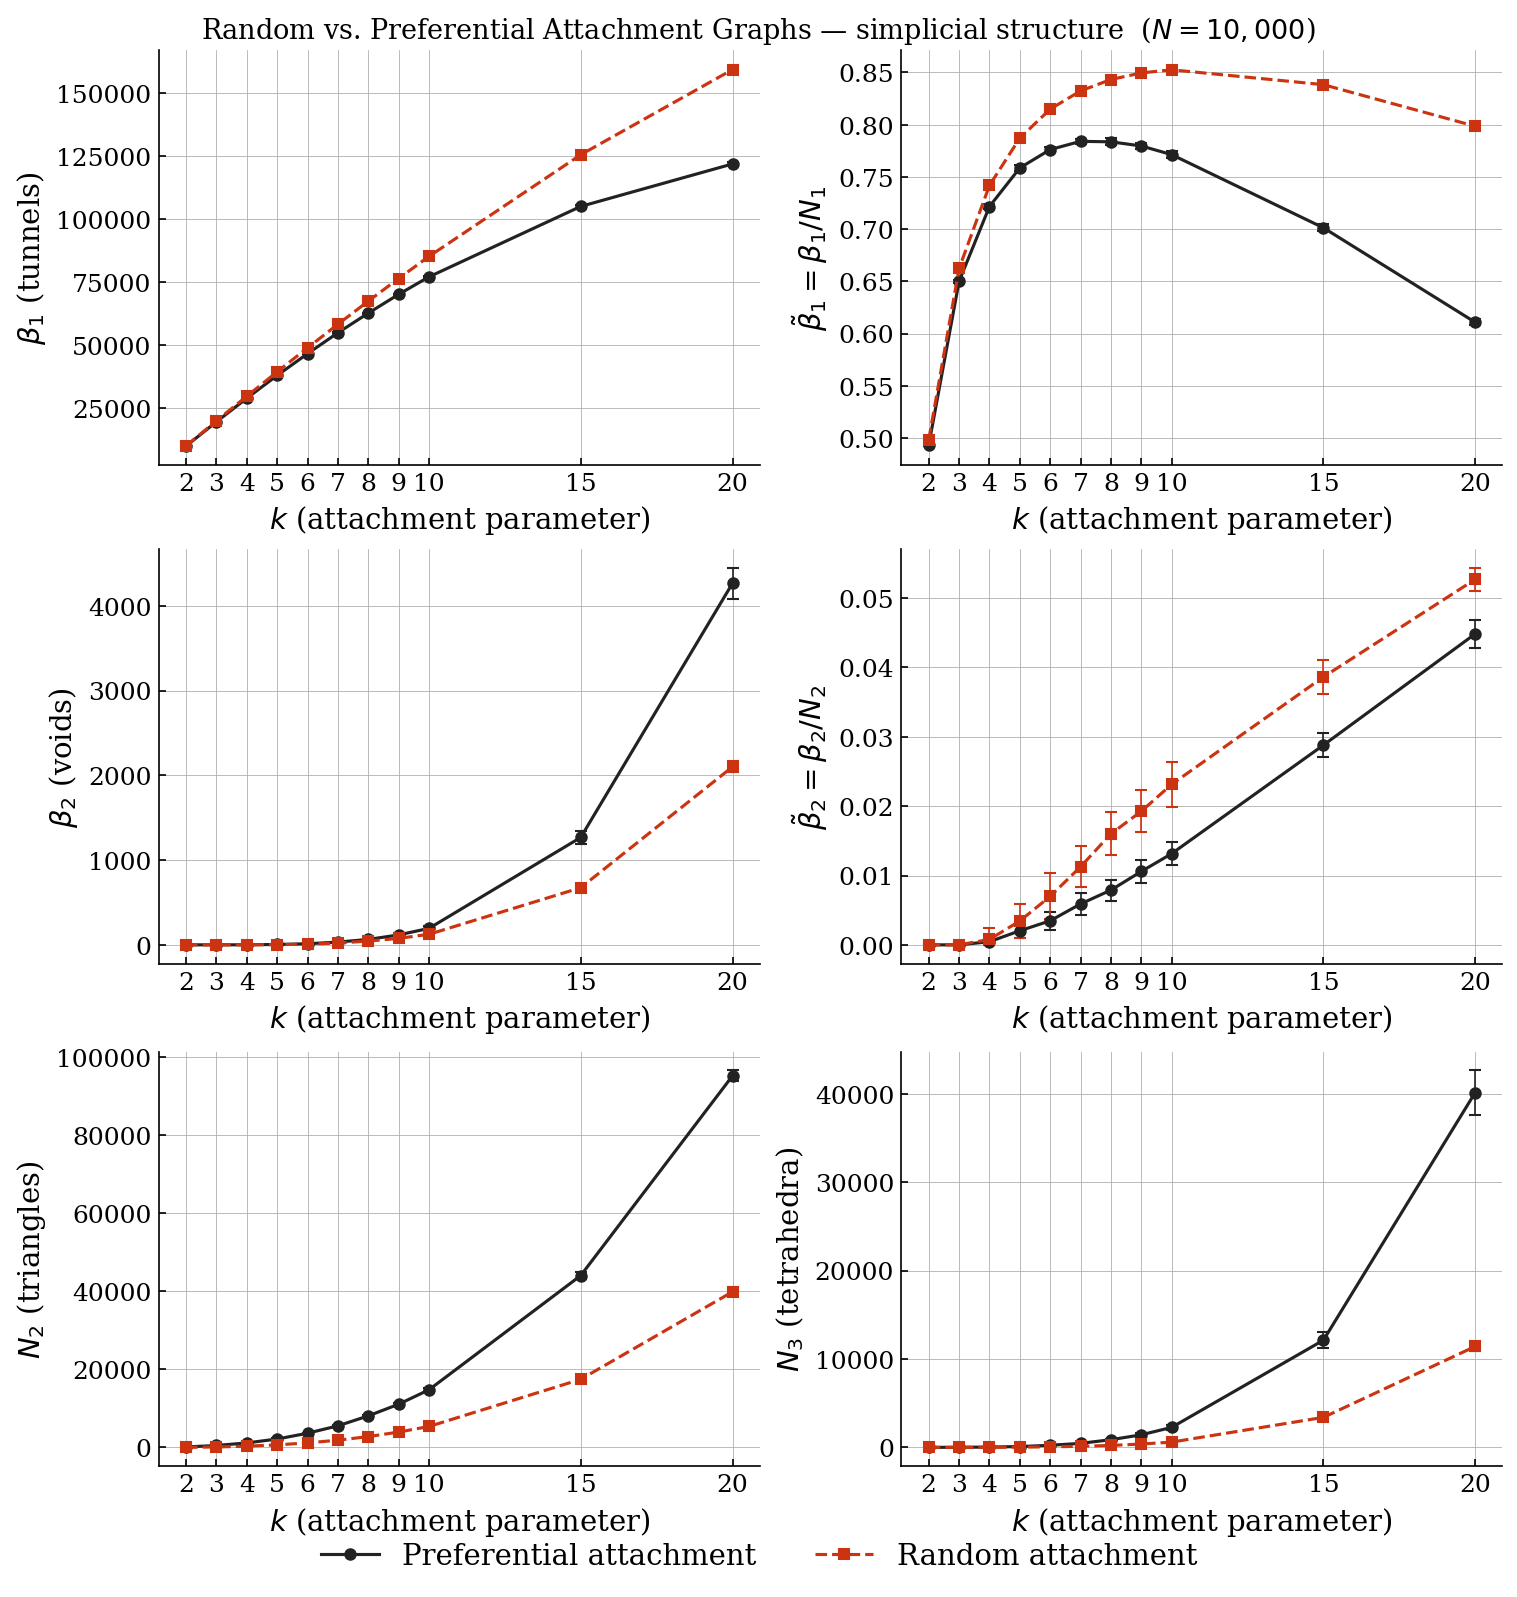

Saved: fig_PA_RA_simplices


/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: divide by zero encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: invalid value encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:35: RuntimeWarning: divide by zero encountered in divide
  (cR2(e) - e[0][2].astype(float))
/tmp/ipykernel_49880/245365849.py:35: RuntimeWarning: invalid value encountered in divide
  (cR2(e) - e[0][2].astype(float))


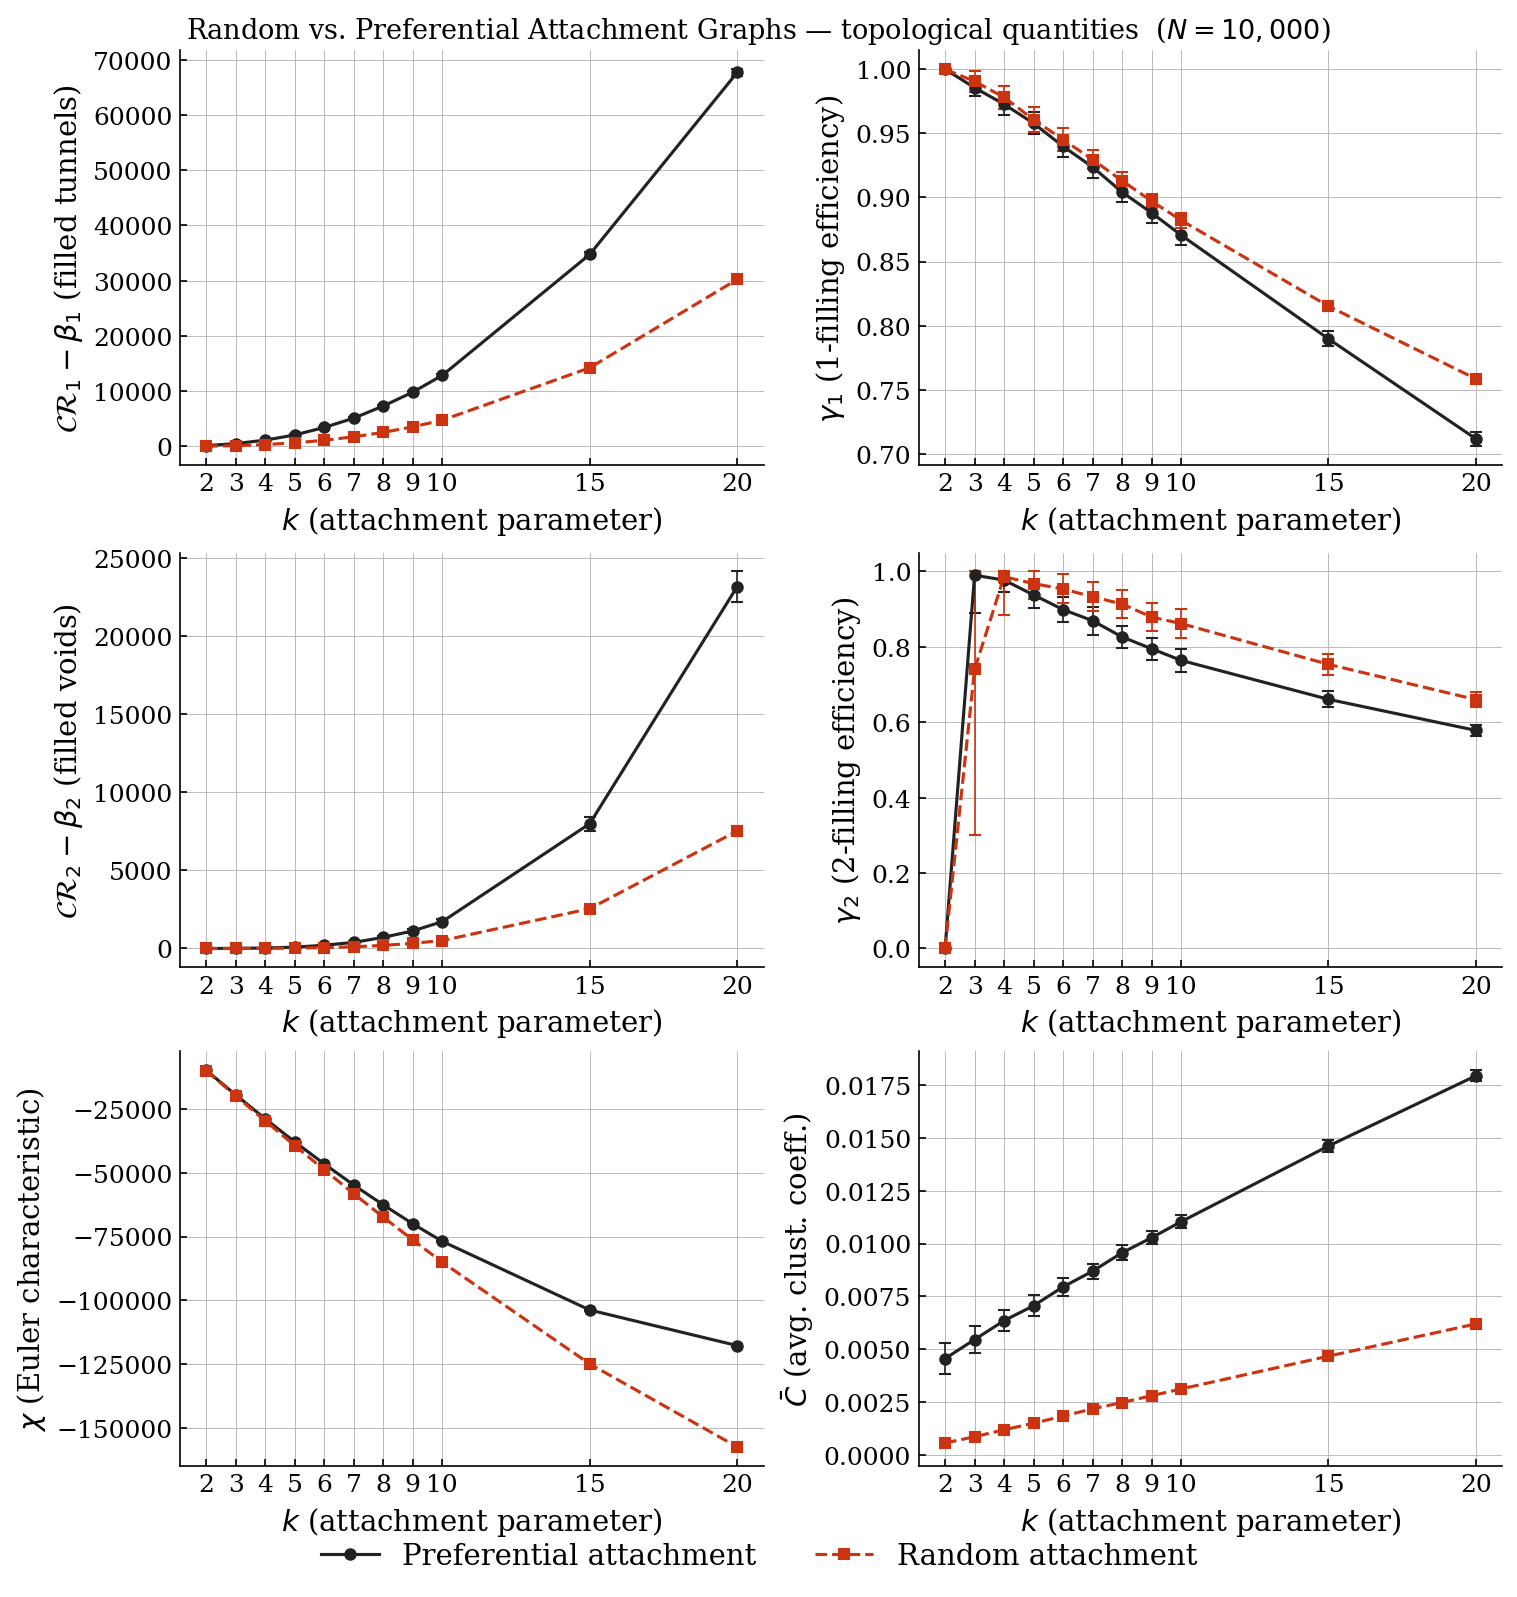

Saved: fig_PA_RA_topology


In [16]:
K_shared = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]

ba_color  = '#222222'
ra_color  = '#CC3311'
errbar_kw = dict(capsize=3, lw=1.5, markersize=5, elinewidth=0.8)

# Quantities bounded in [0, 1] — error bars clipped to these bounds
bounded_labels = {
    r'$\tilde{\beta}_1=\beta_1/N_1$', r'$\tilde{\beta}_2=\beta_2/N_2$',
    r'$\gamma_1$ (1-filling efficiency)',        r'$\gamma_2$ (2-filling efficiency)'}


h_ba = mlines.Line2D([], [], color=ba_color, marker='o', linestyle='-',
                     markersize=5, label='Preferential attachment')
h_ra = mlines.Line2D([], [], color=ra_color, marker='s', linestyle='--',
                     markersize=5, label='Random attachment')

# ============================================================
# Figure 1: β1, β̃1 | β2, β̃2 | N2, N3
# ============================================================
fig1_layout = [
    (r'$\beta_1$ (tunnels)',             r'$\tilde{\beta}_1=\beta_1/N_1$'),
    (r'$\beta_2$ (voids)',             r'$\tilde{\beta}_2=\beta_2/N_2$'),
    (r'$N_2$ (triangles)',                 r'$N_3$ (tetrahedra)'),
]

fig1, axes1 = plt.subplots(3, 2, figsize=(10, 10), constrained_layout=True)

for row_idx, (left, right) in enumerate(fig1_layout):
    for col_idx, label in enumerate([left, right]):
        plot_pa_ra(fields, bounded_labels, data_ba, data_ra, K_shared, iterations,
               ba_color, ra_color, errbar_kw, axes1[row_idx][col_idx], label)

fig1.legend(handles=[h_ba, h_ra], loc='lower center', ncol=2,
            frameon=False, fontsize=14, bbox_to_anchor=(0.5, -0.035))
fig1.suptitle(
    rf'Random vs. Preferential Attachment Graphs — simplicial structure  ($N = {N:,}$)',
    fontsize=13, y=1.02
)
fig1.savefig(base_path_ba + 'fig_PA_RA_simplices.pdf', dpi=300, bbox_inches='tight')
fig1.savefig(base_path_ba + 'fig_PA_RA_simplices.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_PA_RA_simplices')

# ============================================================
# Figure 2: CR1-β1, γ1 | CR2-β2, γ2 | χ, clusterC
# ============================================================
fig2_layout = [
    (r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)',   r'$\gamma_1$ (1-filling efficiency)'),
    (r'$\mathcal{CR}_2 - \beta_2$ (filled voids)',   r'$\gamma_2$ (2-filling efficiency)'),
    (r'$\chi$ (Euler characteristic)',                        r'$\bar{C}$ (avg. clust. coeff.)'),
]

fig2, axes2 = plt.subplots(3, 2, figsize=(10, 10), constrained_layout=True)

for row_idx, (left, right) in enumerate(fig2_layout):
    for col_idx, label in enumerate([left, right]):
        plot_pa_ra(fields, bounded_labels, data_ba, data_ra, K_shared, iterations,
               ba_color, ra_color, errbar_kw, axes2[row_idx][col_idx], label)

fig2.legend(handles=[h_ba, h_ra], loc='lower center', ncol=2,
            frameon=False, fontsize=14, bbox_to_anchor=(0.5, -0.035))
fig2.suptitle(
    rf'Random vs. Preferential Attachment Graphs — topological quantities  ($N = {N:,}$)',
    fontsize=13, y=1.02
)
fig2.savefig(base_path_ba + 'fig_PA_RA_topology.pdf', dpi=300, bbox_inches='tight')
fig2.savefig(base_path_ba + 'fig_PA_RA_topology.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_PA_RA_topology')

## Loading NLPA results

In [17]:
base_path_nlpa  = 'NLPA/'
N          = 10000
K          = [2, 3, 4, 5, 6, 7, 8, 9, 10]
alphas     = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.1, 1.2, 1.3, 1.4, 1.5]
iterations = list(range(1, 11))
num_cores  = 8


all_params = list(product(K, alphas, iterations))

results = Parallel(n_jobs=num_cores, backend='loky')(
    delayed(load_single_nlpa)(N, k, alpha, iteration, base_path_nlpa)
    for k, alpha, iteration in tqdm(all_params, desc='Loading NLPA files'))

# data_nlpa[k][alpha][iteration] = [Betti, SimplexCounts, Euler, D, cycleR, clusterC]
data_nlpa = { k: {alpha: {} for alpha in alphas} for k in K}
missing   = 0
missing_list = []
corrupted = 0
loaded    = 0

for k, alpha, iteration, entry, status in results:
    data_nlpa[k][alpha][iteration] = entry
    if status == 'ok':
        loaded += 1
    elif status == 'missing':
        missing += 1
        filename = os.path.join(base_path_nlpa,f'NLPA_{N}_{k}_{str(alpha).replace(".","_")}_{iteration}.pkl')
        missing_list.append(filename)
    else:
        corrupted += 1
        print(f'  k={k}, alpha={alpha}, iter={iteration}: {status}')

print(f'\nLoaded: {loaded} / {len(all_params)}')
print(f'Missing: {missing}, Corrupted: {corrupted}')

Loading NLPA files:   0%|          | 0/1260 [00:00<?, ?it/s]


Loaded: 1181 / 1260
Missing: 79, Corrupted: 0


## Plotting PA vs RA vs NLPA results

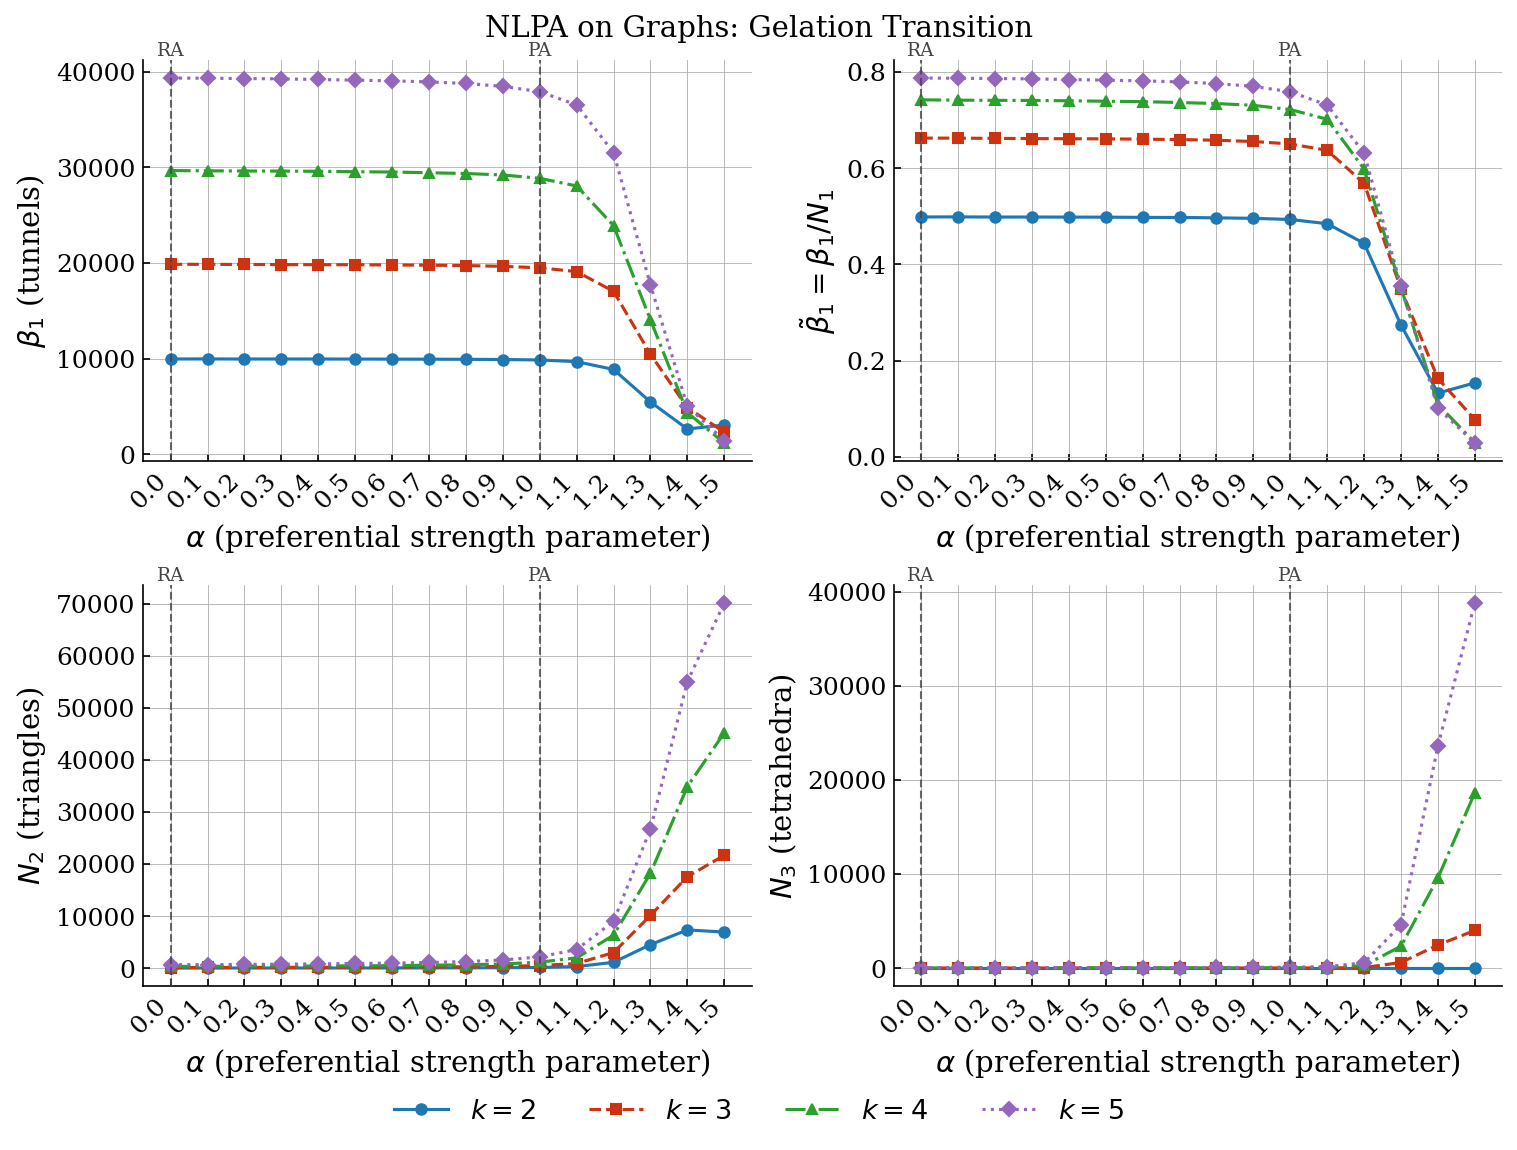

Saved: fig_NLPA_gelation_fig1


/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: divide by zero encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: invalid value encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:91: RuntimeWarning: divide by zero encountered in divide
  (cR1_nlpa(e)
/tmp/ipykernel_49880/245365849.py:91: RuntimeWarning: invalid value encountered in divide
  (cR1_nlpa(e)


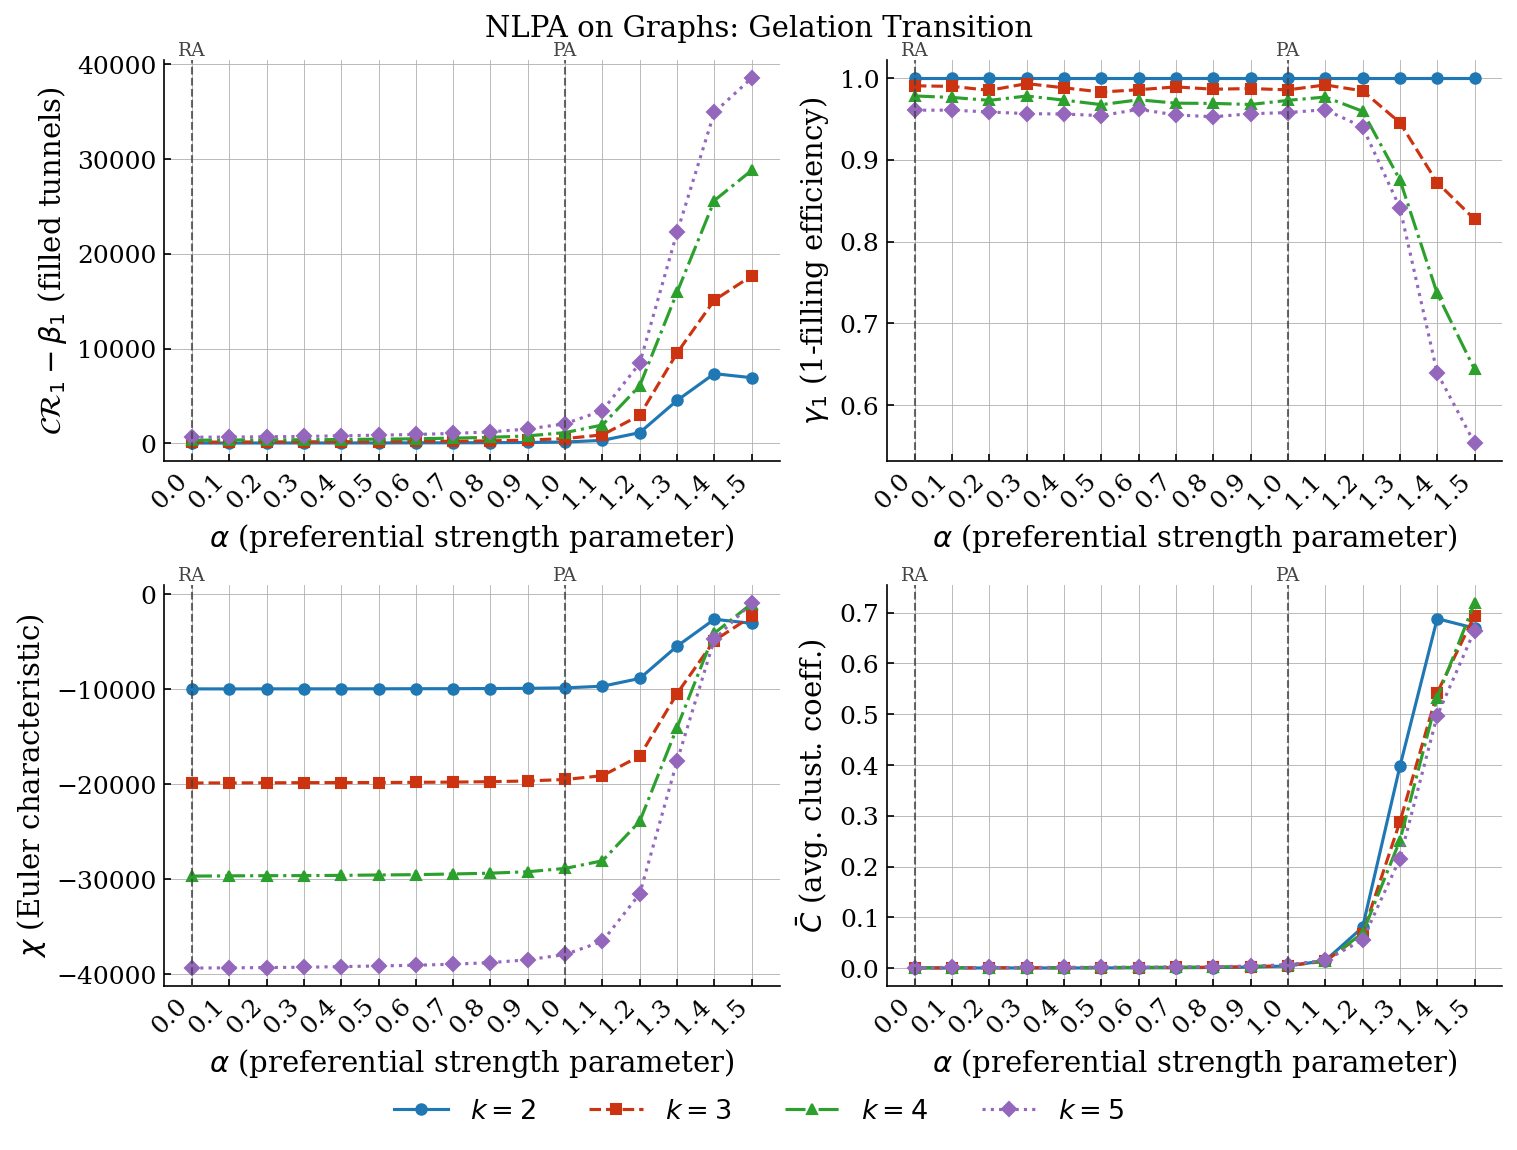

Saved: fig_NLPA_gelation_fig2


/tmp/ipykernel_49880/245365849.py:19: RuntimeWarning: invalid value encountered in divide
  e[0][2] / sc_col(e, 2), 0.0),
/tmp/ipykernel_49880/245365849.py:80: RuntimeWarning: invalid value encountered in divide
  e[0][2] / sc_col(e, 2), 0.0),


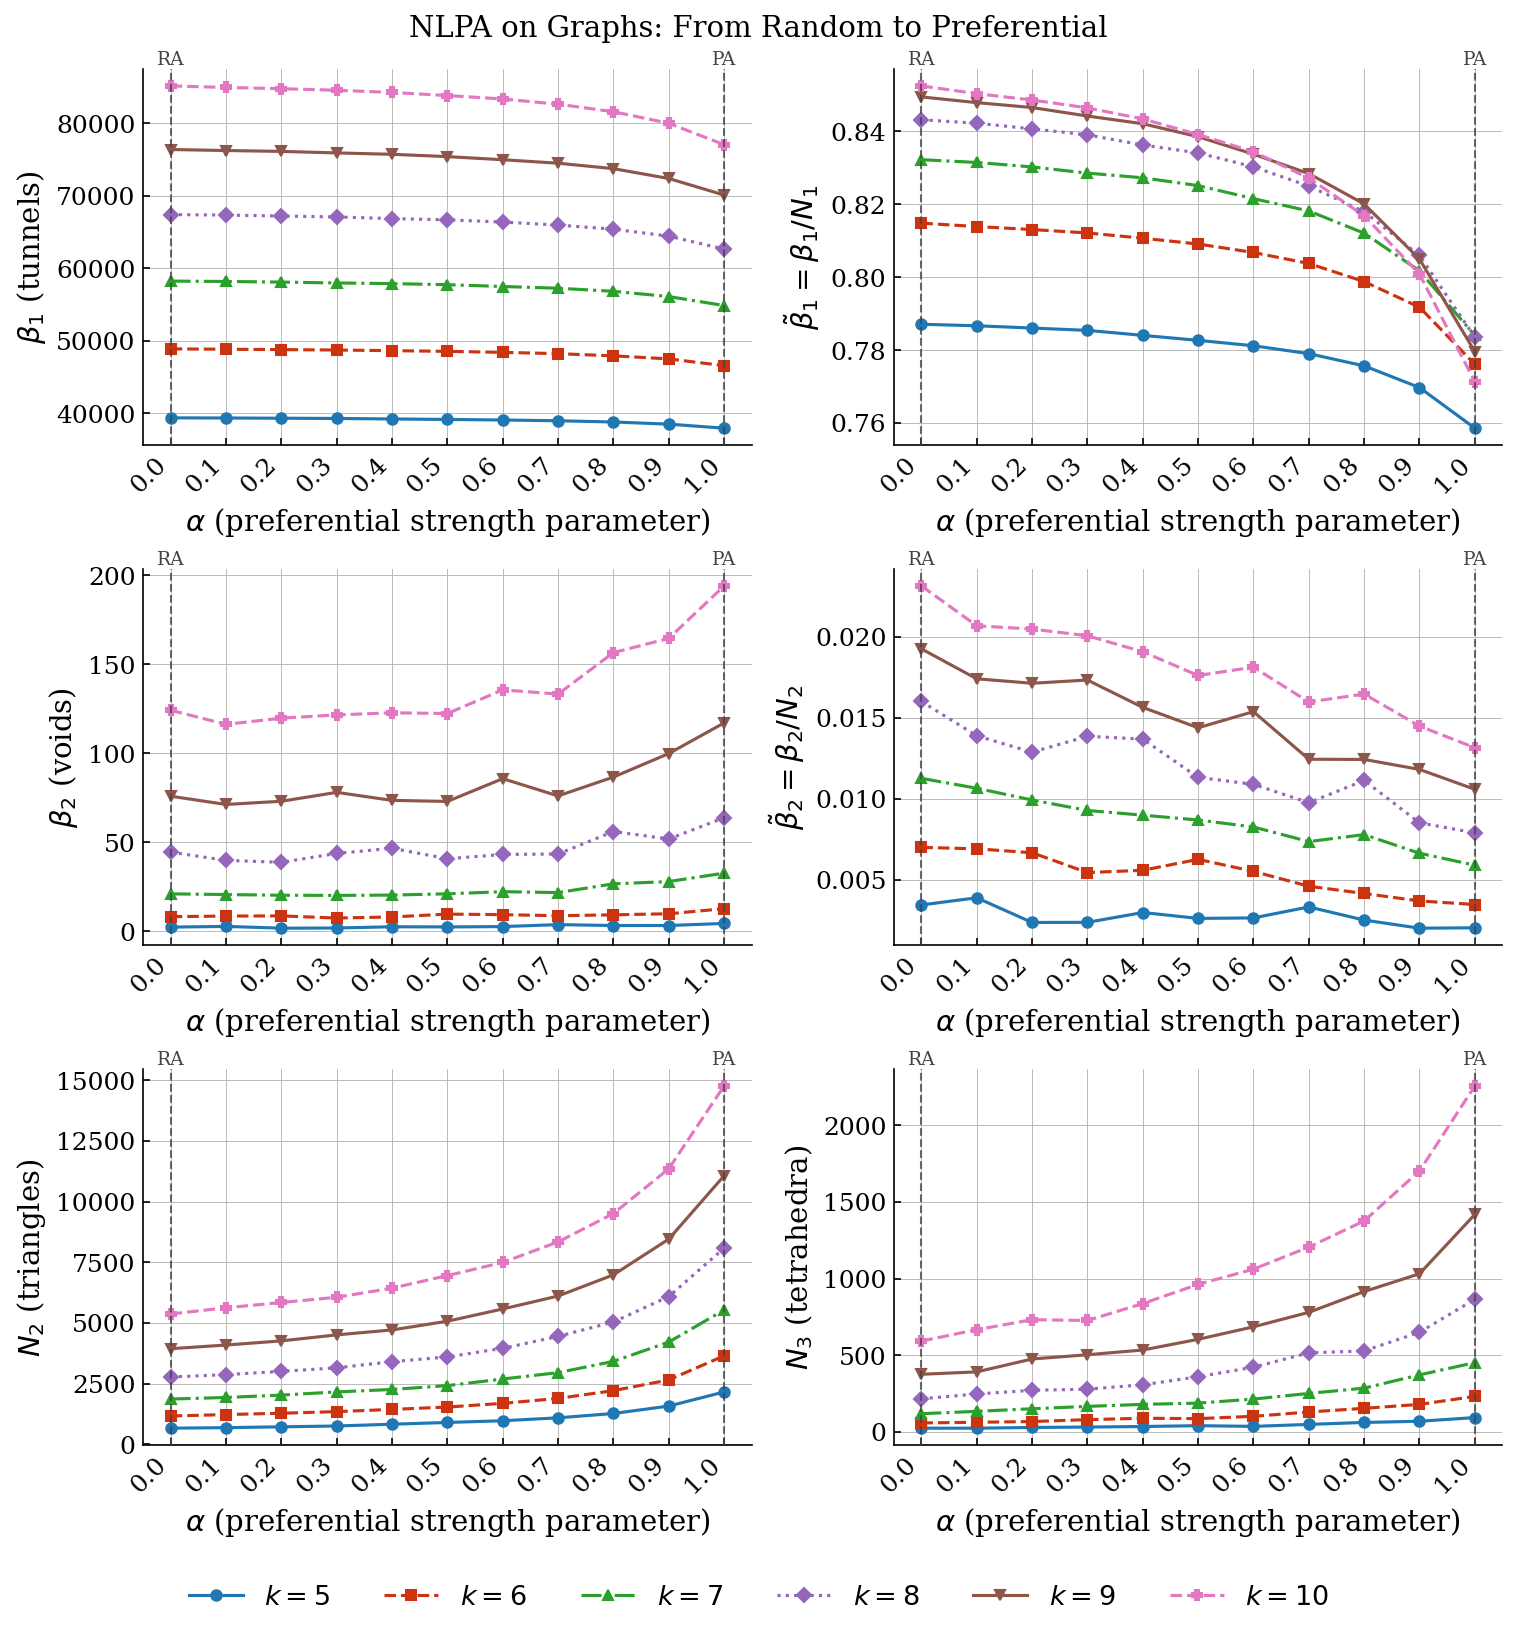

Saved: fig_NLPA_RA_to_PA_fig1


/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: divide by zero encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:29: RuntimeWarning: invalid value encountered in divide
  (cR1(e) - e[0][1].astype(float))
/tmp/ipykernel_49880/245365849.py:91: RuntimeWarning: divide by zero encountered in divide
  (cR1_nlpa(e)
/tmp/ipykernel_49880/245365849.py:91: RuntimeWarning: invalid value encountered in divide
  (cR1_nlpa(e)
/tmp/ipykernel_49880/245365849.py:35: RuntimeWarning: divide by zero encountered in divide
  (cR2(e) - e[0][2].astype(float))
/tmp/ipykernel_49880/245365849.py:35: RuntimeWarning: invalid value encountered in divide
  (cR2(e) - e[0][2].astype(float))
/tmp/ipykernel_49880/245365849.py:96: RuntimeWarning: divide by zero encountered in divide
  (cR2_nlpa(e)
/tmp/ipykernel_49880/245365849.py:96: RuntimeWarning: invalid value encountered in divide
  (cR2_nlpa(e)


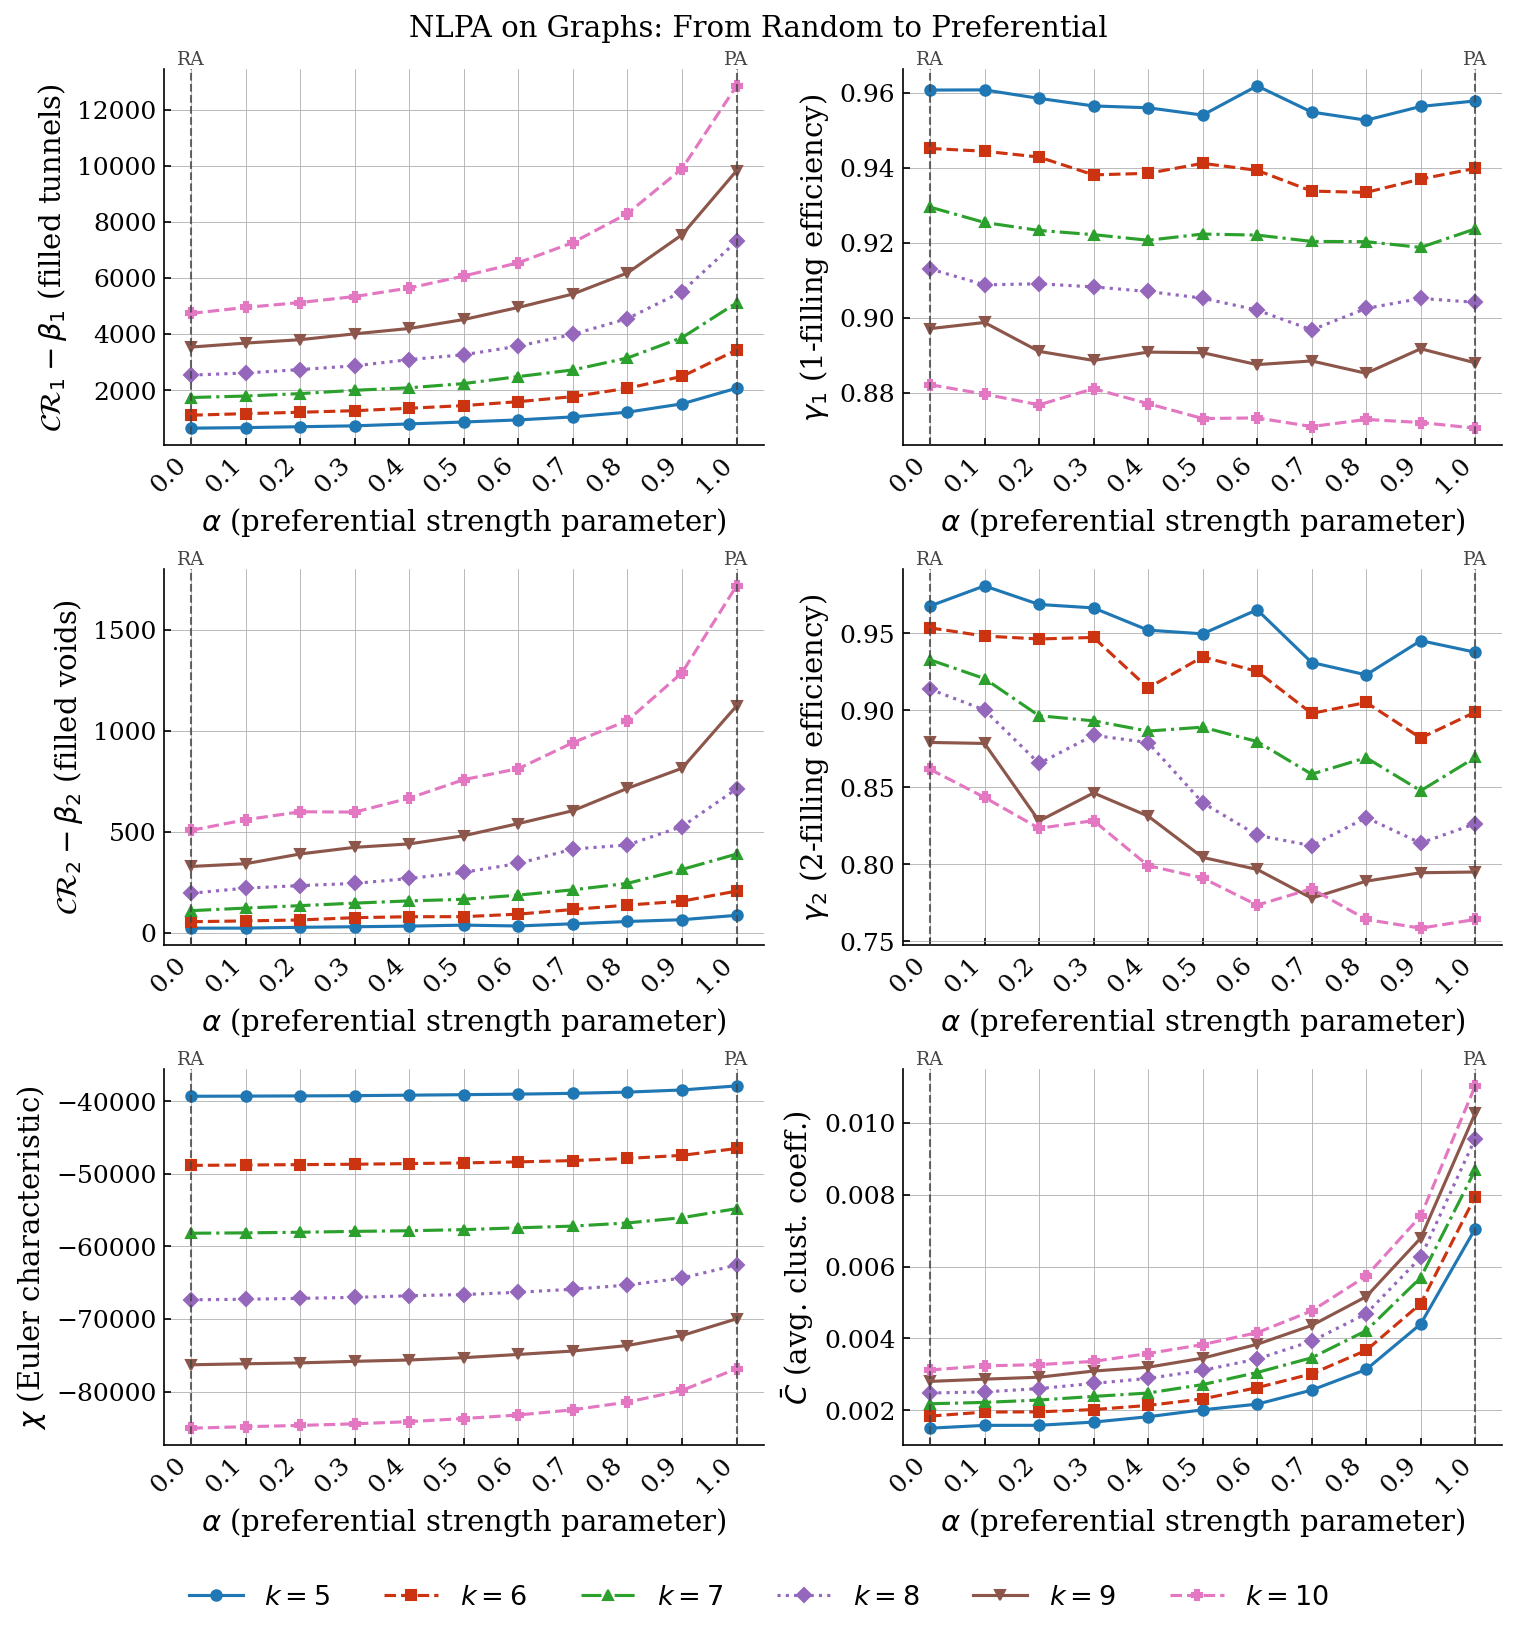

Saved: fig_NLPA_RA_to_PA_fig2


In [18]:
iterations_nlpa  = list(range(1, 11))
iterations_graph = list(range(1, 101))

# ============================================================
# Parameter set 1: Gelation transition
# ============================================================
K_gel           = [2, 3, 4, 5]
alphas_gel      = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,
                   0.8, 0.9, 1.1, 1.2, 1.3, 1.4, 1.5]
alphas_full_gel = sorted([0.0] + alphas_gel + [1.0])

k_styles_gel = {
    2: ('#1f77b4', 'o', '-'),
    3: ('#CC3311', 's', '--'),
    4: ('#2ca02c', '^', '-.'),
    5: ('#9467bd', 'D', ':'),
}

# Gelation Figure 1: β1, β̃1 | N2, N3
draw_nlpa_figure(data_ba, data_ra, data_nlpa, fields, fields_nlpa, iterations_graph, iterations_nlpa,
    panels      = [[r'$\beta_1$ (tunnels)',  r'$\tilde{\beta}_1=\beta_1/N_1$'],
                   [r'$N_2$ (triangles)',      r'$N_3$ (tetrahedra)']],
    nrows=2, ncols=2, figsize=(10, 7),
    suptitle    = 'NLPA on Graphs: Gelation Transition',
    base_path = base_path_nlpa,
    save_prefix = 'fig_NLPA_gelation_fig1',
    K_plot      = K_gel,
    k_styles    = k_styles_gel,
    alphas_full = alphas_full_gel,
)

# Gelation Figure 2: CR1-β1, γ1 | χ, clusterC
draw_nlpa_figure(data_ba, data_ra, data_nlpa, fields, fields_nlpa, iterations_graph, iterations_nlpa,
    panels      = [[r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)',  r'$\gamma_1$ (1-filling efficiency)'],
                   [r'$\chi$ (Euler characteristic)',                        r'$\bar{C}$ (avg. clust. coeff.)']],
    nrows=2, ncols=2, figsize=(10, 7),
    suptitle    = 'NLPA on Graphs: Gelation Transition',
    base_path = base_path_nlpa,
    save_prefix = 'fig_NLPA_gelation_fig2',
    K_plot      = K_gel,
    k_styles    = k_styles_gel,
    alphas_full = alphas_full_gel,
)

# ============================================================
# Parameter set 2: RA to PA transition
# ============================================================
K_ra2pa           = [5, 6, 7, 8, 9, 10]
alphas_ra2pa      = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
alphas_full_ra2pa = sorted([0.0] + alphas_ra2pa + [1.0])

k_styles_ra2pa = {
    5:  ('#1f77b4', 'o',  '-'),
    6:  ('#CC3311', 's',  '--'),
    7:  ('#2ca02c', '^',  '-.'),
    8:  ('#9467bd', 'D',  ':'),
    9:  ('#8c564b', 'v',  '-'),
    10: ('#e377c2', 'P',  '--'),
}

# RA to PA Figure 1: β1, β̃1 | β2, β̃2 | N2, N3
draw_nlpa_figure(data_ba, data_ra, data_nlpa, fields, fields_nlpa, iterations_graph, iterations_nlpa,
    panels      = [[r'$\beta_1$ (tunnels)',  r'$\tilde{\beta}_1=\beta_1/N_1$'],
                   [r'$\beta_2$ (voids)',  r'$\tilde{\beta}_2=\beta_2/N_2$'],
                   [r'$N_2$ (triangles)',      r'$N_3$ (tetrahedra)']],
    nrows=3, ncols=2, figsize=(10, 10),
    suptitle    = 'NLPA on Graphs: From Random to Preferential',
    base_path = base_path_nlpa,
    save_prefix = 'fig_NLPA_RA_to_PA_fig1',
    K_plot      = K_ra2pa,
    k_styles    = k_styles_ra2pa,
    alphas_full = alphas_full_ra2pa,
)

# RA to PA Figure 2: CR1-β1, γ1 | CR2-β2, γ2 | χ, clusterC
draw_nlpa_figure(data_ba, data_ra, data_nlpa, fields, fields_nlpa, iterations_graph, iterations_nlpa,
    panels      = [[r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)',  r'$\gamma_1$ (1-filling efficiency)'],
                   [r'$\mathcal{CR}_2 - \beta_2$ (filled voids)',  r'$\gamma_2$ (2-filling efficiency)'],
                   [r'$\chi$ (Euler characteristic)',        r'$\bar{C}$ (avg. clust. coeff.)']],
    nrows=3, ncols=2, figsize=(10, 10),
    suptitle    = 'NLPA on Graphs: From Random to Preferential',
    base_path = base_path_nlpa,
    save_prefix = 'fig_NLPA_RA_to_PA_fig2',
    K_plot      = K_ra2pa,
    k_styles    = k_styles_ra2pa,
    alphas_full = alphas_full_ra2pa,
)